<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h1>Gaussian Processes</h1>


<div style="text-align: center; margin: 20px 0;">
<img src="Header.PNG" alt="Beyond Chi-Squared: a medieval map of the journey from the Land of χ² into The C" style="max-width: 100%; border-radius: 5px;">
</div>

<details style="margin: 0 0 20px 0; opacity: 0.5;">
<summary style="cursor: pointer; font-size: 0.85em; font-style: italic;">Image Generated with ChatGPT 5.3. Image prompt generated by Claude Opus 4.6, after suggestion by myself. Prompt available.</summary>
<div style="margin-top: 5px; font-size: 0.8em; color: #888;">
Prompt: "COMPOSITION REQUIREMENT: The entire map must be visible within the frame with clear margins on ALL sides. The leftmost landmass must have its full western coastline visible, with at least 5% of the image width as empty parchment/border to its left. Nothing should be cut off at any edge. Frame the composition as if photographing the complete map lying flat on a table. Medieval nautical map in the style of a 16th century portolan chart, aged parchment texture with burnt edges and coffee stains. IMPORTANT: use a wide landscape aspect ratio (roughly 3:1) to ensure nothing is cropped. The LEFT THIRD of the map shows a fully visible landmass labelled in ornate blackletter script "THE LAND OF χ²" with small illustrated towns, roads, farmland, and a castle, all drawn in the flat overhead style of medieval cartography. The coastline is detailed with depth soundings. The landmass must be FULLY VISIBLE, not cropped at the edge. From the eastern shore, a medieval sailing ship (a single-masted cog with a large square sail) ventures into open water. CRITICAL STYLE INSTRUCTION: the ship and its crew of 3-4 figures must be drawn in the FLAT, SIDE-PROFILE style of the Bayeux Tapestry — bold black outlines, no perspective, no shading, no depth, elongated proportions, figures shown in strict profile with pointed feet. The sail reads "HMAS OCCAM" in the Bayeux embroidery style. One figure points forward, another reads a scroll, a third peers through a spyglass. The ocean occupies the RIGHT TWO-THIRDS of the map and is labelled in large flowing calligraphy "THE C" (with the C in a mathematical bold serif font, distinct from the medieval lettering). The water transitions from calm ripples near the shore to turbulent stylised medieval wave patterns further out. In the far right waters, sea monsters emerge: a serpent whose scales form a grid pattern resembling a covariance matrix, and a kraken whose individual tentacles are each clearly labelled with kernel function names (Matérn, RBF, Periodic, Quasi-Periodic) written directly along the tentacles like text on a ribbon. Above the monsters, a weathered cartouche banner reads in Gothic blackletter: "HIC SVNT DRACONES." Small rocky islands dot the sea, each with a label on a tiny scroll or banner: "Off-Diagonal Terms," "det C," "O(N³)," "Cholesky Reef." A compass rose in the bottom-left corner with standard cardinal directions (N, S, E, W). The overall colour palette is warm sepia, faded reds, and muted blues. The entire image should look like a single flat medieval map viewed from directly above — NO three-dimensional perspective, NO vanishing points, NO realistic lighting."
</div>
</details>

<h2>Structure</h2>

| Part | Topic | Type |
|:----:|-------|------|
| 0 | Why Gaussian Processes? | Motivation |
| 1 | Beyond χ²: Correlated Noise | Conceptual + Math |
| 2 | Kernel Functions | Math + Code |
| 3 | GP Regression: Prior to Posterior | Math + Code |
| 4 | Hyperparameter Learning | Math + Code |
| 5 | tinygp in Practice | Code |
| 6 | Computational Cost | Conceptual |


<h2>What this notebook covers</h2>

We build Gaussian processes from the ground up, starting from χ² and the covariance matrix, through kernel functions and GP regression, to hyperparameter learning and practical implementation with tinygp. By the end, you will (hopefully) understand how GPs work, why they work, and how to use them.

<b>Estimated reading time:</b> 60–90 minutes (including running code cells).

<h2>Preamble</h2>

- This notebook builds the mathematical and conceptual foundation for Gaussian processes. You will read and run this before the in-person tutorial.
- You will not need to write code from scratch, only run it.
- Reading Guide: Sections marked with "🏛️ Historical Aside" are anecdotes and context. They are completely skippable, but can be fun.
- Short on time? Read §0, §1.1–1.3, §2.3–2.6, §3.1–3.5, and §4.1–4.2. Skip the historical asides, collapsible boxes, and §6.
- Key references: Rasmussen &amp; Williams (2006) Ch.2 &amp; 5, Aigrain &amp; Foreman-Mackey (2023) ARA&amp;A

<h2>Library Imports</h2>
Please make sure that you have the following packages imported before the tutorial. It may be a wise idea to start a new python environment for this tutorial. You can install packages within jupyter cells by running <code>!pip install tinygp</code> for example.
</div>

In [1]:
# Standard Packages
import numpy as np
import matplotlib.pyplot as plt

# Simple optimisation Function
from scipy.optimize import minimize

# Cool and Important Maths Library
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

# Our Gaussian Process Library
import tinygp
import time

# Data for the Mauna Loa example
from statsmodels.datasets import co2

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">
 
<h1>§0. Why Gaussian Processes?</h1>
 
Gaussian Processes are perhaps the most beautiful statistical tools. I mean this literally — the plots they create are just so nice. However, the mathematics for Gaussian processes (GPs) is dense and not trivial. As such, we will start with a motivating example, where we will treat the GP as a black box. Don't worry about the code yet — just look at the result.
 
<h2>0.1 Sausage Plots</h2>
 
Below, we have noisy observations of some unknown function. The data is dense in three locations, but there are wide gaps in the middle where we have no observations at all. We will fit a GP to this data.
 
</div>


In [2]:
# === Create Data ============================================== #
# Just some wiggly stuff, no real model                          #
# ============================================================== #
np.random.seed(161)

# True function: something wiggly
def true_func(x):
    return np.sin(2 * np.pi * x) + 0.25 * np.cos(4 * np.pi * x)

# Dense data on the edges, gap in the middle
x_left  = np.random.uniform(0.0, 0.25, 30)
x_mid   = np.random.uniform(0.45, 0.55, 10)
x_right = np.random.uniform(0.75, 1.0, 30)
x_obs = np.sort(np.concatenate([x_left, x_mid, x_right]))

# Observations with moderate noise
sigma_obs = 0.15
y_obs = true_func(x_obs) + np.random.normal(0, sigma_obs, len(x_obs))

# Prediction grid
x_pred = np.linspace(0, 1, 500)

In [3]:
# === GP fit =================================================== #
# We derive all of this later. For now, just observe the result. #
# ============================================================== #

def build_gp(params, x):
    log_amp, log_ell, log_sigma = params
    kernel = jnp.exp(2 * log_amp) * tinygp.kernels.Matern52(scale=jnp.exp(log_ell))
    return tinygp.GaussianProcess(
        kernel, x, diag=jnp.exp(2 * log_sigma) * jnp.ones_like(x)
    )

@jax.jit
def neg_log_mlik(params, x, y):
    return -build_gp(params, x).log_probability(y)

x_obs_jax = jnp.array(x_obs)
y_obs_jax = jnp.array(y_obs)
x_pred_jax = jnp.array(x_pred)

result = minimize(
    neg_log_mlik,
    x0=jnp.log(jnp.array([0.5, 0.1, 0.15])),
    args=(x_obs_jax, y_obs_jax),
    method='Nelder-Mead'
)

gp = build_gp(jnp.array(result.x), x_obs_jax)
cond_gp = gp.condition(y_obs_jax, x_pred_jax).gp
mu_gp = np.array(cond_gp.loc)
std_gp = np.sqrt(np.array(cond_gp.variance))

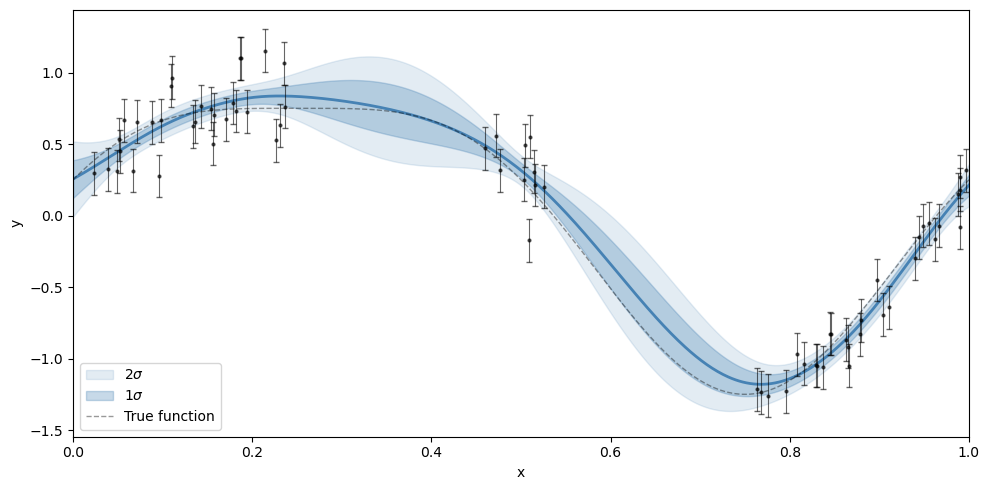

In [4]:
# === Plotting Code ============================================ #
# See the beauty                                                 #
# ============================================================== #
fig, ax = plt.subplots(figsize=(10, 5))

# Uncertainty bands
ax.fill_between(x_pred, mu_gp - 2*std_gp, mu_gp + 2*std_gp, 
                alpha=0.15, color='steelblue', label=r'$2\sigma$')
ax.fill_between(x_pred, mu_gp - std_gp, mu_gp + std_gp, 
                alpha=0.3, color='steelblue', label=r'$1\sigma$')

# GP mean
ax.plot(x_pred, mu_gp, 'steelblue', lw=2)

# True function
ax.plot(x_pred, true_func(x_pred), 'k--', alpha=0.4, lw=1, label='True function')

# Data
ax.errorbar(x_obs, y_obs, yerr=sigma_obs, fmt='k.', ms=4, elinewidth=0.8, 
            capsize=2, alpha=0.6)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(0, 1)
ax.legend(loc='lower left')
plt.tight_layout()

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">
 
This plot is sometimes known as a "sausage plot", and it is really neat. The solid line is the GP's best estimate of the function, and the shaded bands show the $1\sigma$ and $2\sigma$ uncertainty envelopes.
 
Notice how the bands behave:
<ul>
<li>Where data is dense, the bands are tight. The GP is confident about the function.</li>
<li>Where data is absent, the bands balloon outward. We should be less confident in regions where we have less data!</li>
</ul>
 
One of the nice things about GPs is that they give you a data-density-dependent estimate of how uncertain the fit is. Compare this to methods like polynomial fitting, where the uncertainty bands are more or less uniform.
 
<h2>0.2 When noise has structure</h2>
 
The sausage plot demonstrates one virtue of GPs: honest, spatially varying uncertainty. But the arguably more important reason to care about GPs is <b>correlated noise</b>.
 
In the example above, the noise was independent: each data point was scattered randomly around the true function, with no relationship between the scatter at one point and the next. This assumption is behind ordinary least squares, behind $\chi^2$ fitting, and behind most of the statistical machinery you've been taught.
 
In real astronomical data, this assumption is almost never exactly true (although it can be approximately true). Detector systematics, atmospheric effects, spacecraft pointing jitter, and instrumental drifts all produce noise that is correlated whether in time, in wavelength, or something else. When a pixel scatters high, its neighbours tend to scatter high too. The noise has <i>structure</i>.
 
This matters because if you ignore correlations, you <b>overestimate how much information your data contains</b>. You have $N$ data points, but if the noise is correlated, the effective number of independent measurements is much smaller than $N$. The result are error bars that are too small, significances that are too high, and in pathological cases false detections of spurious signals. We will see a real example of this shortly (§1.4).
 
But first, we need to understand the mathematics of how correlations enter the likelihood.
 
</div>


<div style="max-width: 800px; margin: 0 auto; text-align: justify;">
 
<h1>§1. Beyond $\chi^2$: An extended introduction to correlated noise and Gaussian processes</h1>
 
<i>This title is 100% my original work and is definitely not copied from this ancient <a href="https://astrobites.org/2014/07/01/beyond-chi-squared-an-introduction-to-correlated-noise/">astrobites article</a> by some grad student.</i>
 
<h2>1.1 Recap: Least Squares as Maximum Likelihood</h2>
 
Typically, our noise model says that each observation is drawn from a Gaussian centred on the true value:
 
$$y_i \sim \mathcal{N}(m_i(\boldsymbol{\theta}),\; \sigma_i^2)$$
 
Recall that $\mathcal{N}$ is the notation for the normal (Gaussian) distribution. Here $m_i(\boldsymbol{\theta})$ is the model prediction at the $i$-th data point (i.e. the model $m$ with parameters $\boldsymbol{\theta}$, evaluated at input $i$), and $\sigma_i^2$ is the variance. Writing out the Gaussian PDF explicitly, the probability of observing $y_i$ given the model is:
 
$$P(y_i \mid \boldsymbol{\theta}) = \frac{1}{\sqrt{2\pi\sigma_i^2}} \exp\!\left[ -\frac{(y_i - m_i(\boldsymbol{\theta}))^2}{2\sigma_i^2} \right]$$
 
If the errors are <b>independent</b> (i.e. that knowing that one measurement scattered high tells you nothing about the next) the joint probability of all $N$ observations is the product:
 
$$\mathcal{L}(\boldsymbol{\theta}) = \prod_{i=1}^{N} P(y_i \mid \boldsymbol{\theta})$$
 
Taking the logarithm turns the product into a sum:
 
$$\ln \mathcal{L}(\boldsymbol{\theta}) = -\frac{1}{2} \sum_{i=1}^{N} \left[ \frac{(y_i - m_i(\boldsymbol{\theta}))^2}{\sigma_i^2} + \ln(2\pi\sigma_i^2) \right]$$
 
<details class="alert alert-info" style="margin: 10px 0;">
<summary style="cursor: pointer; font-weight: bold;">Where does the $\ln(2\pi\sigma_i^2)$ come from?</summary>
<div style="margin-top: 10px;">
 
Take the log of the PDF for a single data point:
 
$$\ln P(y_i \mid \boldsymbol{\theta}) = \ln\!\left(\frac{1}{\sqrt{2\pi\sigma_i^2}}\right) - \frac{(y_i - m_i)^2}{2\sigma_i^2}$$
 
The first term is the log of the prefactor. Since $\ln(1/\sqrt{x}) = -\frac{1}{2}\ln(x)$:
 
$$\ln\!\left(\frac{1}{\sqrt{2\pi\sigma_i^2}}\right) = -\frac{1}{2}\ln(2\pi\sigma_i^2)$$
 
Sum over all $i$ and factor out the $-\frac{1}{2}$, and you get the expression above.
 
</div>
</details>
 
The second term doesn't depend on $\boldsymbol{\theta}$, so maximising the log-likelihood is equivalent to minimising:
 
$$\boxed{\chi^2(\boldsymbol{\theta}) = \sum_{i=1}^{N} \frac{(y_i - m_i(\boldsymbol{\theta}))^2}{\sigma_i^2}}$$
 
This is a sum of squared residuals, weighted by the noise variance — i.e. a (weighted) least-squares objective. To summarise:
 
<b>Least-squares fitting is maximum likelihood estimation under the assumption of independent Gaussian errors.</b>
 
So far, that should have been a recap. I know the notation can be dense, but all we have said is that the optimal model is the one that minimises the square of the residuals (weighted by their variance).
 
<h2>1.2 Matrix Notation</h2>
 
We will now rewrite $\chi^2$ in matrix notation, step-by-step, so you can see that GPs are a natural extension of $\chi^2$ to correlated noise.
 
<h3>1.2.1 The sum is a dot product</h3>
 
To simplify notation, suppose all uncertainties are equal: $\sigma_i = \sigma$ for all $i$. Then:
 
$$\chi^2 = \frac{1}{\sigma^2} \sum_{i=1}^{N} (y_i - m_i)^2$$
 
Define the residual vector:
 
$$\mathbf{r} = \mathbf{y} - \mathbf{m}(\boldsymbol{\theta}) = \begin{pmatrix} y_1 - m_1 \\ y_2 - m_2 \\ \vdots \\ y_N - m_N \end{pmatrix}$$
 
Note that the sum of squared residuals is just the dot product of this vector with itself:
 
$$\sum_{i=1}^{N} (y_i - m_i)^2 = \mathbf{r}^T \mathbf{r}$$
 
To make this abundantly clear, write it out for $N = 3$:
 
$$\mathbf{r}^T \mathbf{r} = \begin{pmatrix} r_1 & r_2 & r_3 \end{pmatrix} \begin{pmatrix} r_1 \\ r_2 \\ r_3 \end{pmatrix} = r_1^2 + r_2^2 + r_3^2$$
 
So matrix multiplication is just a compact way of writing summation. With this, $\chi^2 = \frac{1}{\sigma^2}\, \mathbf{r}^T \mathbf{r}$.
 
<h3>1.2.2 The matrix in the middle</h3>
 
We can insert the identity matrix without changing anything:
 
$$\chi^2 = \frac{1}{\sigma^2}\, \mathbf{r}^T \mathbf{I}\, \mathbf{r}$$
 
The identity matrix encodes the fact that each residual is weighted equally (all values are 1) and independently (only the diagonal is non-zero).
 
What happens if we change this matrix? The diagonal entries control the *weight* of each data point, and the off-diagonal entries control the *coupling* between data points. The identity matrix (all 1s on the diagonal, all 0s off it) says "weight everything equally, couple nothing." That is the independence assumption, written as a matrix.
 
<details class="alert alert-info" style="margin: 10px 0;">
<summary style="cursor: pointer; font-weight: bold;">Worked example: playing with the $3 \times 3$ matrix</summary>
<div style="margin-top: 10px;">
 
I encourage you to do these matrix multiplications in your head. Right now, we have:
 
$$\begin{pmatrix} r_1 & r_2 & r_3 \end{pmatrix} \begin{pmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix} \begin{pmatrix} r_1 \\ r_2 \\ r_3 \end{pmatrix} = r_1^2 + r_2^2 + r_3^2$$
 
Every residual contributes equally. But what happens if we change this matrix?
 
<b>Changing a diagonal entry.</b> Replace the (2,2) entry with 2:
 
$$\begin{pmatrix} r_1 & r_2 & r_3 \end{pmatrix} \begin{pmatrix} 1 & 0 & 0 \\ 0 & 2 & 0 \\ 0 & 0 & 1 \end{pmatrix} \begin{pmatrix} r_1 \\ r_2 \\ r_3 \end{pmatrix} = r_1^2 + 2r_2^2 + r_3^2$$
 
The second data point now contributes twice as much to the sum. Changing the diagonal entries changes the weight of each residual. This is exactly what happens when data points have different uncertainties: a measurement with smaller $\sigma_i$ should count for more, and we achieve this by putting a larger number on the corresponding diagonal entry.
 
<b>Adding an off-diagonal entry.</b> Now put a non-zero value off the diagonal:
 
$$\begin{pmatrix} r_1 & r_2 & r_3 \end{pmatrix} \begin{pmatrix} 1 & 0.5 & 0 \\ 0.5 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix} \begin{pmatrix} r_1 \\ r_2 \\ r_3 \end{pmatrix} = r_1^2 + r_1 r_2 + r_2^2 + r_3^2$$
 
<i>(Note that these matrices must be symmetric about the diagonal.)</i>
 
Something new has appeared: a cross-term $r_1 r_2$. The contributions of data points 1 and 2 are no longer independent! The value of $r_1$ affects how much $r_2$ contributes, and vice versa. If both residuals have the same sign (both scatter high, or both scatter low), the cross-term is positive and the overall sum increases. The off-diagonal entry has coupled the two data points.
 
</div>
</details>

<h3>1.2.3 Unequal uncertainties</h3>
 
Now go back to the general case where each data point has its own uncertainty $\sigma_i$:
 
$$\chi^2 = \sum_{i=1}^{N} \frac{r_i^2}{\sigma_i^2}$$
 
This is no longer $\mathbf{r}^T \mathbf{r}$, because each term has a different weight. But we can write it as $\mathbf{r}^T \mathbf{W} \, \mathbf{r}$ if we choose the right matrix $\mathbf{W}$. We need the matrix that, when sandwiched between $\mathbf{r}^T$ and $\mathbf{r}$, produces the weighted sum. Writing it out for $N = 3$:
 
$$\begin{pmatrix} r_1 & r_2 & r_3 \end{pmatrix} \begin{pmatrix} 1/\sigma_1^2 & 0 & 0 \\ 0 & 1/\sigma_2^2 & 0 \\ 0 & 0 & 1/\sigma_3^2 \end{pmatrix} \begin{pmatrix} r_1 \\ r_2 \\ r_3 \end{pmatrix} = \frac{r_1^2}{\sigma_1^2} + \frac{r_2^2}{\sigma_2^2} + \frac{r_3^2}{\sigma_3^2}$$
 
So $\mathbf{W} = \text{diag}(1/\sigma_1^2, \ldots, 1/\sigma_N^2)$. This is the inverse of the matrix:
 
$$\mathbf{C} = \begin{pmatrix} \sigma_1^2 & 0 & \cdots & 0 \\ 0 & \sigma_2^2 & \cdots & 0 \\ \vdots & & \ddots & \vdots \\ 0 & 0 & \cdots & \sigma_N^2 \end{pmatrix}$$
 
and so $\chi^2 = \mathbf{r}^T \mathbf{C}^{-1} \mathbf{r}$.
 
<h2>1.3 The Covariance Matrix $\mathbf{C}$</h2>
 
The matrix $\mathbf{C}$ is the <b>covariance matrix</b> of the noise. Its diagonal entries $C_{ii} = \sigma_i^2$ are the variances, which is what we have seen before. The new part is the off-diagonal entries $C_{ij}$ (for $i \neq j$). These are the covariances between the noise at different data points. Right now they are all zero, which is the independence assumption.
 
<h3>1.3.1 The full likelihood</h3>
 
The $\chi^2$ term $\mathbf{r}^T \mathbf{C}^{-1} \mathbf{r}$ is only the exponent of the Gaussian PDF. Recall that the scalar Gaussian PDF also had the prefactor $1/\sqrt{2\pi\sigma_i^2}$ out front. The matrix version of the full PDF is the multivariate Gaussian, which has a slightly different normalisation:
 
$$P(\mathbf{y} \mid \boldsymbol{\theta}) = \frac{1}{\sqrt{(2\pi)^N \det \mathbf{C}}} \exp\!\left[-\frac{1}{2}\,\mathbf{r}^T \mathbf{C}^{-1}\mathbf{r}\right]$$
 
The $\det \mathbf{C}$ in the denominator is the normalisation. It plays the same role as $\sigma$ in the scalar case. In one dimension, a wider Gaussian (larger $\sigma$) needs a shorter peak to integrate to 1. In $N$ dimensions, $\det \mathbf{C}$ measures the "volume" of the error ellipsoid, and a larger volume means a more spread-out distribution that needs a smaller prefactor. For diagonal $\mathbf{C}$, $\det \mathbf{C} = \prod_i \sigma_i^2$, and the prefactor reduces to $\prod_i \frac{1}{\sqrt{2\pi\sigma_i^2}}$, the product of the individual normalisations.
 
<details class="alert alert-info" style="margin: 10px 0;">
<summary style="cursor: pointer; font-weight: bold;">Why $\det \mathbf{C}$ is not (necessarily) a constant</summary>
<div style="margin-top: 10px;">
 
Although $\det \mathbf{C}$ is a normalisation factor, it is not necessarily a constant as it depends on what we put inside $\mathbf{C}$. If the entries of $\mathbf{C}$ are fixed numbers (known measurement uncertainties), then yes, it's a constant you can ignore. But if $\mathbf{C}$ has free parameters that we want to learn from the data — which is exactly what a GP will do — then $\det \mathbf{C}$ changes as those parameters change, and it affects the likelihood.
 
In fact, this term acts as <b>Occam's razor</b>. A more flexible covariance structure (larger $\det \mathbf{C}$) spreads the probability over a larger volume of data space, which <i>decreases</i> the likelihood at any particular observed dataset. So even if a flexible $\mathbf{C}$ fits the data better (smaller data-fit term), it pays a penalty through $\ln \det \mathbf{C}$ for that flexibility. The marginal likelihood automatically penalises unnecessary complexity. If you did the nested sampling tutorial, this is the same mechanism as the Bayesian evidence, just in a different guise: there it was the prior volume shrinkage, here it's the normalisation of the multivariate Gaussian. We'll return to this properly in §4.
 
</div>
</details>
 
Taking the logarithm:
 
$$\boxed{\ln \mathcal{L}(\boldsymbol{\theta}) = -\frac{1}{2} \left[ \underbrace{\mathbf{r}^T \mathbf{C}^{-1} \mathbf{r}}_{\text{data-fit (generalised } \chi^2\text{)}} + \underbrace{\ln \det \mathbf{C}}_{\text{normalisation}} + \underbrace{N \ln 2\pi}_{\text{constant}} \right]}$$
 
This equation is completely general. It works for any positive-definite (read: invertible) covariance matrix, diagonal or not. Everything that follows in this notebook is a consequence of choosing what to put inside $\mathbf{C}$.
 
<h2>1.4 Correlated Errors</h2>
 
Now suppose the errors are correlated. Perhaps your detector has read noise that is spatially correlated, sky subtraction has left a gradient residual in your image, or you have red noise from instrumental drifts.
 
When errors are independent, we can write the joint probability as a product of individual Gaussians, one per data point. That is what we are doing when we write the likelihood $\mathcal{L} = \prod_i P(y_i \mid \boldsymbol{\theta})$. But we can only multiply probabilities like this if they are independent. If the noise at point $i$ is correlated with the noise at point $j$, then $P(y_i)$ and $P(y_j)$ are not independent, and the joint probability does not factorise into a product. You cannot describe the noise by specifying each $\sigma_i$ separately. You also need to know how the noise at different points relates to each other.
 
The multivariate Gaussian from §1.3.1 already handles this. The only thing that changes is that $\mathbf{C}$ is no longer diagonal:
 
$$\mathbf{C} = \begin{pmatrix} \sigma_1^2 & C_{12} & \cdots & C_{1N} \\ C_{21} & \sigma_2^2 & \cdots & C_{2N} \\ \vdots & & \ddots & \vdots \\ C_{N1} & C_{N2} & \cdots & \sigma_N^2 \end{pmatrix}$$
 
The diagonal entries are still the variances of each measurement. The entry $C_{ij}$ for $i \neq j$ is the covariance between the noise at data points $i$ and $j$. If $C_{ij} > 0$, then when data point $i$ scatters high, data point $j$ tends to scatter high too.
 
The log-likelihood is the same equation</b> as before, only $\mathbf{C}$ has changed. But the consequences are significant: $\mathbf{C}^{-1}$ is now a full matrix, so $\mathbf{r}^T \mathbf{C}^{-1} \mathbf{r}$ contains cross-terms (just like the off-diagonal example in §1.2).

The effect of the cross terms quantify our intuition: If two data points have correlated noise, they are partially redundant, as knowing one tells us something about the other. So the second doesn't contribute a full "new measurement" worth of information. The generalised $\chi^2$ accounts for this as correlated residuals contribute less to $\mathbf{r}^T \mathbf{C}^{-1} \mathbf{r}$ than they would under a diagonal $\mathbf{C}$

<details class="alert alert-info" style="margin: 10px 0;">
<summary style="cursor: pointer; font-weight: bold;">Worked example: what $\mathbf{C}^{-1}$ actually does (2D)</summary>
<div style="margin-top: 10px;">


Take two data points with residuals $r_1$ and $r_2$, and suppose their noise is strongly positively correlated:
 
$$\mathbf{C} = \begin{pmatrix} 1 & 0.8 \\ 0.8 & 1 \end{pmatrix}$$
 
<b>Diagonal (wrong) case:</b> if you ignore the correlation and use $\mathbf{C} = \mathbf{I}$, you compute $\chi^2 = r_1^2 + r_2^2$. Both residuals count fully. If both scatter high by +1, you get $\chi^2 = 2$.
 
<b>Full $\mathbf{C}$ case:</b> the inverse is:
 
$$\mathbf{C}^{-1} = \frac{1}{1 - 0.64}\begin{pmatrix} 1 & -0.8 \\ -0.8 & 1 \end{pmatrix} = \begin{pmatrix} 2.78 & -2.22 \\ -2.22 & 2.78 \end{pmatrix}$$
 
Now compute $\mathbf{r}^T \mathbf{C}^{-1} \mathbf{r}$ with $r_1 = r_2 = 1$ (both scatter high together):
 
$$\begin{pmatrix} 1 & 1 \end{pmatrix} \begin{pmatrix} 2.78 & -2.22 \\ -2.22 & 2.78 \end{pmatrix} \begin{pmatrix} 1 \\ 1 \end{pmatrix} = 2.78 - 2.22 - 2.22 + 2.78 = 1.11$$
 
$\chi^2$ drops from 2 to 1.11. Both points scattered high, but because their noise is positively correlated, this is expected. It is not strong evidence against the model, so $\chi^2$ is smaller. The precision matrix ($\mathbf{C}^{-1}$) has down-weighted this pattern.
 
Now try $r_1 = +1, r_2 = -1$ (they scatter in opposite directions):
 
$$\begin{pmatrix} 1 & -1 \end{pmatrix} \begin{pmatrix} 2.78 & -2.22 \\ -2.22 & 2.78 \end{pmatrix} \begin{pmatrix} 1 \\ -1 \end{pmatrix} = 2.78 + 2.22 + 2.22 + 2.78 = 10.0$$
 
$\chi^2 = 10$, versus 2 if you had ignored the correlations. Scattering in opposite directions is unlikely given strongly positively correlated noise, so the precision matrix amplifies this as it is unexpected.
 
<b>The geometry.</b> The eigendecomposition of $\mathbf{C}$ gives two perpendicular directions:

<ul>
<li>Along $r_1 = r_2$ (the "both scatter together" direction), with eigenvalue $1 + 0.8 = 1.8$. Correlated fluctuations are expected and "cheap."</li>
<li>Along $r_1 = -r_2$ (the "scatter oppositely" direction), with eigenvalue $1 - 0.8 = 0.2$. Anti-correlated fluctuations are rare and "expensive."</li>
</ul>

When you compute $\mathbf{r}^T \mathbf{C}^{-1} \mathbf{r}$, you are projecting the residuals onto these natural directions and dividing by the corresponding eigenvalue. The cheap direction contributes little; the expensive direction contributes a lot.

The figure below shows this geometrically. The shaded region is the $1\sigma$ contour of the noise distribution.
 
<ul>
<li><b>Left panel</b> ($\mathbf{C} = \mathbf{I}$, independent noise): the contour is a circle. Both residual vectors give $\chi^2 = 2$, and both sit just outside the $1\sigma$ boundary.</li>
<li><b>Right panel</b> ($\rho = 0.8$, correlated noise): the contour stretches into an ellipse along the correlated direction. The red residual (both scatter high) now gives $\chi^2 = 1.1$, barely outside the $1\sigma$ boundary. The blue residual (opposite directions) gives $\chi^2 = 10$ and lies far outside.</li>
</ul>
 
Although we have the residuals, we have a different $\chi^2$, because the geometry of "what counts as surprising" has changed, now that we have updated the covariance matrix.
 
<img src="correlated_ellipse.png" alt="Side-by-side comparison of independent (circle) vs correlated (ellipse) noise geometry" style="max-width: 100%; margin: 10px 0;">

</div>
</details>

Now let's see how this affects actual model fitting. We generate data from a straight line with exponentially correlated noise (closer points are strongly correlated, with correlations dropping with distance), then fit it two ways: once using the correct full covariance matrix, and once pretending the errors are independent.

As before, the below code isn't too important, just the plot it produces.

</div>

In [5]:
np.random.seed(42)

# True model: a straight line
N = 50
t = np.linspace(0, 10, N)
true_slope, true_intercept = 0.5, 2.0
true_model = true_slope * t + true_intercept

# Build a covariance matrix with exponential correlations
sigma = 1.0          # marginal std dev
ell = 2.0            # correlation length
C_true = sigma**2 * np.exp(-np.abs(t[:, None] - t[None, :]) / ell)

# Draw correlated noise and add to model
noise = np.random.multivariate_normal(np.zeros(N), C_true)
data = true_model + noise

In [6]:
def fit_line(t, data, C):
    '''
    Generalised least squares: fit a straight line using covariance matrix C.
    =========================================================================
    Input:
        - t    : np.array. Independent variable.
        - data : np.array. Observations.
        - C    : np.array, shape (N, N). Covariance matrix.
    Output:
        - params     : np.array, [slope, intercept].
        - cov_params : np.array, shape (2, 2). Parameter covariance.
    '''
    A = np.vstack([t, np.ones_like(t)]).T  # design matrix
    C_inv = np.linalg.inv(C)
    cov_params = np.linalg.inv(A.T @ C_inv @ A)
    params = cov_params @ A.T @ C_inv @ data
    return params, cov_params

# Fit with WRONG covariance (diagonal — ignoring correlations)
C_wrong = np.diag(np.diag(C_true))  # strip off-diagonal entries
params_wrong, cov_wrong = fit_line(t, data, C_wrong)

# Fit with CORRECT covariance (full matrix)
params_correct, cov_correct = fit_line(t, data, C_true)

print("True parameters:      slope = {:.3f}, intercept = {:.3f}".format(
    true_slope, true_intercept))
print("Diagonal C (wrong):   slope = {:.3f} ± {:.3f}, intercept = {:.3f} ± {:.3f}".format(
    params_wrong[0], np.sqrt(cov_wrong[0, 0]), 
    params_wrong[1], np.sqrt(cov_wrong[1, 1])))
print("Full C (correct):     slope = {:.3f} ± {:.3f}, intercept = {:.3f} ± {:.3f}".format(
    params_correct[0], np.sqrt(cov_correct[0, 0]), 
    params_correct[1], np.sqrt(cov_correct[1, 1])))

True parameters:      slope = 0.500, intercept = 2.000
Diagonal C (wrong):   slope = 0.445 ± 0.048, intercept = 1.942 ± 0.279
Full C (correct):     slope = 0.461 ± 0.134, intercept = 1.784 ± 0.857


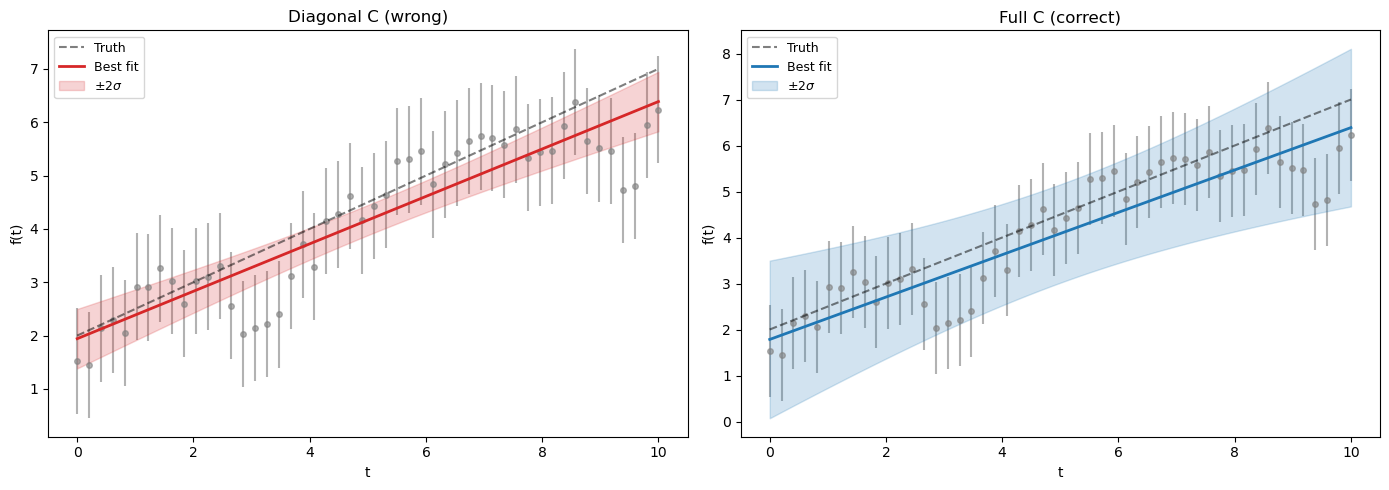

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, params, cov_p, title, color in [
    (axes[0], params_wrong, cov_wrong, 'Diagonal C (wrong)', 'tab:red'),
    (axes[1], params_correct, cov_correct, 'Full C (correct)', 'tab:blue')]:
    
    ax.errorbar(t, data, yerr=np.sqrt(np.diag(C_true)), fmt='o', ms=4, 
                color='grey', alpha=0.6, zorder=1)
    ax.plot(t, true_model, 'k--', lw=1.5, label='Truth', alpha=0.5)
    
    # Best fit + uncertainty band from parameter covariance
    t_fine = np.linspace(0, 10, 200)
    A_fine = np.vstack([t_fine, np.ones_like(t_fine)]).T
    model_fine = A_fine @ params
    var_fine = np.sum((A_fine @ cov_p) * A_fine, axis=1)
    
    ax.plot(t_fine, model_fine, color=color, lw=2, label='Best fit')
    ax.fill_between(t_fine, model_fine - 2*np.sqrt(var_fine), 
                    model_fine + 2*np.sqrt(var_fine), alpha=0.2, color=color,
                    label=r'$\pm 2\sigma$')
    
    ax.set_title(title)
    ax.set_xlabel('t')
    ax.set_ylabel('f(t)')
    ax.legend(fontsize=9)

plt.tight_layout()

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

Pay particular attention to the uncertainty bands. On the left, we have assumed that the errors are independent (i.e. the covariance matrix is the identity matrix). On the right, we have fit it with the actual covariance matrix. 

The left plot reports uncertainty bands that are much too small (i.e. overconfident). It has placed parts of the true line outside of the 2 sigma credible region. It has done this because it thinks it has $N=50$ independent measurements, when it effectively has fewer points. The correct fit, on the right, has larger uncertainty bands, but they reflect what we can actually know. Furthermore, they actually contain the true model. 

So: if we knew the correct $\mathbf{C}$, we'd be done. We would just plug it into the likelihood from §1.3.1 and fit as usual, with more honest/accurate error bars that account for the correlations. 

**But we almost never know $\mathbf{C}$.** We also can't just directly fit for $\mathbf{C}$ either as unlike a diagonal $\mathbf{C}$ (which has $N$ free parameters, one per $\sigma_i$), a non-diagonal $\mathbf{C}$ has $N(N+1)/2$ unique entries. For $N = 1000$, that is about half a million parameters, far more than the data can constrain. So we need to be clever about how to fit $\mathbf{C}$. We need to impose structure on $\mathbf{C}$, reducing half a million numbers to a handful of parameters. That is exactly what a <b>kernel function</b> does, and it is the heart of what GPs are.

----------------

</div>

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">
    
<h2>1.5 🏛️ Historical Aside: Methane Mirages - Miscalibration Masquerading as Molecules a.k.a. the Swain / Gibson affair</h2>

Before we move on to kernels, here is a real case where ignoring correlated noise led to a false discovery (but *a lot* of citations!), and where GPs provided the fix. Before getting started, it should be noted that this section is just a retelling of a historical arc, and makes no statements about the legitimacy / quality of the science being done in any of the papers cited. The paper that started this saga, did not do anything out of the ordinary at the time, and was more or less following standard procedure for the time. It was, however, arguably the (one of) catalyst for the subsequent adoption of Gaussian Processes in Astronomy.

<h3>Detection</h3>

In 2008, Swain, Vasisht & Tinetti published a result in Nature: the first detection of methane (CH₄) in the atmosphere of an exoplanet (<a href="https://doi.org/10.1038/nature06823">Swain et al. 2008</a>). Using transmission spectroscopy with the HST/NICMOS instrument, they observed the hot Jupiter HD 189733b (a ~1,200 K gas giant orbiting a K-type star 63 light-years away) as it transited its host star. They reported absorption features from both water and methane. This result, particularly the methane, is notable because it implies disequilibrium chemistry. Essentially, there must be something causing this excess of methane as thermochemical equilibrium  suggests that CO should be strongly favoured over CH$_4$. On Earth, methane is maintained far above equilibrium almost entirely by biological processes. While their detection does not necessarily imply (nor did they claim) evidence of biology, it did demonstrate a proof of concept for detecting astrobiologically interesting molecules on exoplanets. 

However, there was a problem of systematic noise. 

NICMOS observations, like any instrument, is affected by instrumental systematics. The measured flux depends not only the astrophysical signal, but on other factors such as the position of the spectral trace on the detector, the width / angle of the trace, the detector temperature, and the spacecraft's orbital phase. All of these produce *time-correlated* noise that is much larger than the $\sim0.1%$ molecular absorption signal that was 'detected'.

Swain et al. handled this in the standard way. They modelled the systematics as a <b>linear function of</b> "optical state parameters" (trace position, width, angle, temperature, HST orbital phase). For each wavelength channel, they fit something like:

$$F(t) = f_0 + \beta_1 \cdot \Delta X + \beta_2 \cdot \Delta Y _  + \beta_3 \cdot W + \beta_4 \cdot \theta + \beta_5 \cdot T  + \beta_6 \cdot \phi_H + \beta_7 \cdot \phi_H^2 $$

then subtracted this from their data and fit a transit model to the residual. This is essentially doing ordinary least squares decorrelation. It is important to note that they have *chosen* (implicitly or explicitly) to use a linear functional form of their nuisance signal.

<h3>Reanalysis</h3>

In 2011, Gibson, Pont & Aigrain reanalysed the same NICMOS dataset (<a href="https://doi.org/10.1111/j.1365-2966.2010.17837.x">Gibson et al. 2011</a>). Their approach was to use the <b>same linear decorrelation technique</b> but systematically vary the choices within it. They tried different combinations of optical state parameters, used different out-of-transit orbits for the baseline, and replaced linear functions with quadratic ones.

The transmission spectrum changed depending on which systematics model was chosen. The methane feature appeared with some models and vanished with others. Different, equally defensible choices of which parameters to include produced different spectra. They concluded that there was no principled way to select among the models, and therefore no conclusive evidence for molecular features. The problem was that the data could not distinguish between the astrophysical signal and the instrumental systematics under any of the linear basis models. The model space was too restrictive, and the data were insufficiently constraining.

<h3>The Gaussian Process Solution</h3>

The following year, the same team proposed a fix (<a href="https://doi.org/10.1111/j.1365-2966.2011.19915.x">Gibson et al. 2012, MNRAS 419, 2683</a>).

Essentially, the problem was the linear approach, which enforced a specific functional form for the systematics. If the true dependence was non-linear, or involved interactions between variables, the linear model couldn't capture it. The leftover systematic structure would end up in the residuals, and in this case the residual structure was almost pathological which gave rise to the mistaken methane signature. But because the correlations weren't properly taken care of, they got small error bars which gave them false confidence (*"the observations decisively show that methane is present"*) 

A Gaussian process avoids this by not committing to any specific functional form. Instead, it says: "the systematic dependence on these auxiliary variables is <i>some</i> smooth function, and I will consider <i>all</i> smooth functions consistent with the data." The GP encodes assumptions about smoothness and correlation structure (through a kernel function, which we will see in §2), but not a specific formula. It then marginalises over the entire space of functions, rather than picking one.

We don't yet have the machinery to understand the details of how this works. That is what §2–§8 of this notebook are for. But to give a flavour: Gibson et al. used a squared exponential kernel with a separate length-scale parameter for each auxiliary variable, so that the GP could automatically determine which variables mattered and which didn't (a technique called Automatic Relevance Determination). If the data indicated that detector temperature was irrelevant, the GP effectively switched it off. No manual model selection required.

The results were conclusive:
<ul>
<li>The transmission spectrum was broadly consistent with previous analyses, but with <b>significantly larger error bars</b>. The GP accurately reported how uncertain the answer was, given that the functional form of the systematics was unknown.</li>
<li>The methane feature at ~2.2 μm was no longer statistically significant.</li>
<li>The result was now robust to the choice of input variables. Unlike the linear decorrelation, adding or removing auxiliary parameters did not qualitatively change the spectrum.</li>
</ul>

If a linear model had been adequate, the GP would have recovered the same spectrum (the GP includes linear functions as a special case). The fact that it produced larger error bars demonstrated that the linear model had been overfitting systematics as signal.

<h3>Epilogue</h3>

The question was finally settled by JWST. <a href="https://doi.org/10.1038/s41586-024-07760-y">Fu et al. (2024, Nature)</a> obtained high-precision transmission spectroscopy of HD 189733b and detected H₂O, CO₂, CO, and H₂S, but placed a strong upper limit on methane of just 0.1 ppm. This confirmed what thermochemical models had always predicted: at ~1,200 K, carbon should overwhelmingly exist as CO, not CH₄. The original detection was  an artefact of the systematic correction.

------------------

</div>

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h1>§2. Kernel Functions</h1>

In §1, we arrived at a general log-likelihood that works for any covariance matrix $\mathbf{C}$:

$$\ln \mathcal{L} = -\frac{1}{2}\left[\mathbf{r}^T \mathbf{C}^{-1} \mathbf{r} + \ln\det\mathbf{C} + N\ln 2\pi\right]$$

We also saw that $\mathbf{C}$ has $N(N+1)/2$ unique entries, which exceeds $N$ for any $N>2$. This means that the matrix is underdetermined as there are always more covariance parameters than data points. Fitting $\mathbf{C}$ directly is not feasible.  

However, let us not miss the forest for the trees. We can't fit the covariance of every data point with every other data point, but we don't actually need to. Instead, we can describe the *structure* of the correlations. For example, I can't tell you the exact number of photons that will land on my solar panel at 1:52pm tomorrow, but I can tell you it will probably be similar to the number of photons that landed on it at 1:51pm and 1:53pm (because the sky changes slowly), and it will be similar to 1:52pm today (because the Sun has a 24-hour period). I don't know every pairwise covariance, but I know the rules (or I can fit the rules) generating them. In that example, nearby times are correlated, and there was a periodic component.

What we want to do is to parameterise $\mathbf{C}$  with a function. Instead of treating every entry $C_{ij}$ as a free parameter, we assume the covariance between two data points depends on their separation through some function with a small number of free parameters:

$$C_{ij} = k(x_i, x_j) $$

The function $k$ is called a <b>kernel function</b> (or covariance function). It takes two input locations and returns the covariance between the function values at those locations. Different kernels encode different assumptions about the underlying function e.g, how smooth it is, whether it is periodic, and how quickly correlations decay with separation.

A <b>Gaussian process</b> is just a way of building $\mathbf{C}$ from a kernel, and then doing inference with the same likelihood you already know. The only difference is that $\mathbf{C}$ now depends on a handful of hyperparameters (amplitude, length scale, period, etc.) that you also learn from the data.

If you have ever added a "jitter" term $\sigma_j$ in quadrature to your error bars, you have already done the simplest possible version of this: you modified the diagonal of $\mathbf{C}$. A GP extends the idea to the off-diagonals.

</div>

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>2.1 Visualising the covariance matrix</h2>

Before we look at specific kernels, let's build some intuition for what a covariance matrix actually encodes. Suppose we have 50 data points equally spaced in time (as we did above). Rather than leaving $\mathbf{C}$ diagonal, we now fill it in with a kernel function that makes nearby points correlated and distant points independent, as this better represents our assumptions about the noise.We will use the squared exponential kernel (don't worry about the name for now, it's just a function and we will see this and several others properly in §2.3). This is similar in spirit to the exponentially correlated noise we used in the line-fitting comparison above but with a Gaussian decay rather than an exponential one

$$C_{ij} = k(t_i,\, t_j) = A^2 \exp\!\left(-\frac{|t_i - t_j|^2}{2\ell^2}\right) + \sigma_n^2\,\delta_{ij}$$

with $A = 1$, $\ell = 1.5$, and $\sigma_n = 0.3$. Here $A$ is the amplitude of the correlated signal, $\ell$ is the length scale (how quickly correlations decay with separation), $\sigma_n$ is the uncorrelated measurement noise, and $\delta_{ij}$ is the Kronecker delta ($\delta_{ij} = 1$ if $i = j$, and 0 otherwise), so the $\sigma_n^2$ term only appears on the diagonal. For now we have fixed these values by hand, but in practice, $A$, $\ell$, and (sometimes) $\sigma_n$ are <b>hyperparameters</b> that we learn from the data. We will see how to do this in §4.

Below, we visualise this matrix. As before, the code itself is not too important:
</div>

In [8]:
# === Visualising the covariance matrix ===
np.random.seed(42)

N = 50
t = np.linspace(0, 10, N)
true_slope, true_intercept = 0.5, 2.0
true_model = true_slope * t + true_intercept

# Kernel parameters
A = 1.0
ell = 1.5
sigma_n = 0.3

# Build C
C = A**2 * np.exp(-0.5 * ((t[:, None] - t[None, :]) / ell)**2) + sigma_n**2 * np.eye(N)

# Generate one realisation
noise = np.random.multivariate_normal(np.zeros(N), C)
data = true_model + noise

# Pick a reference point
ref = 15
cov_col = C[:, ref]

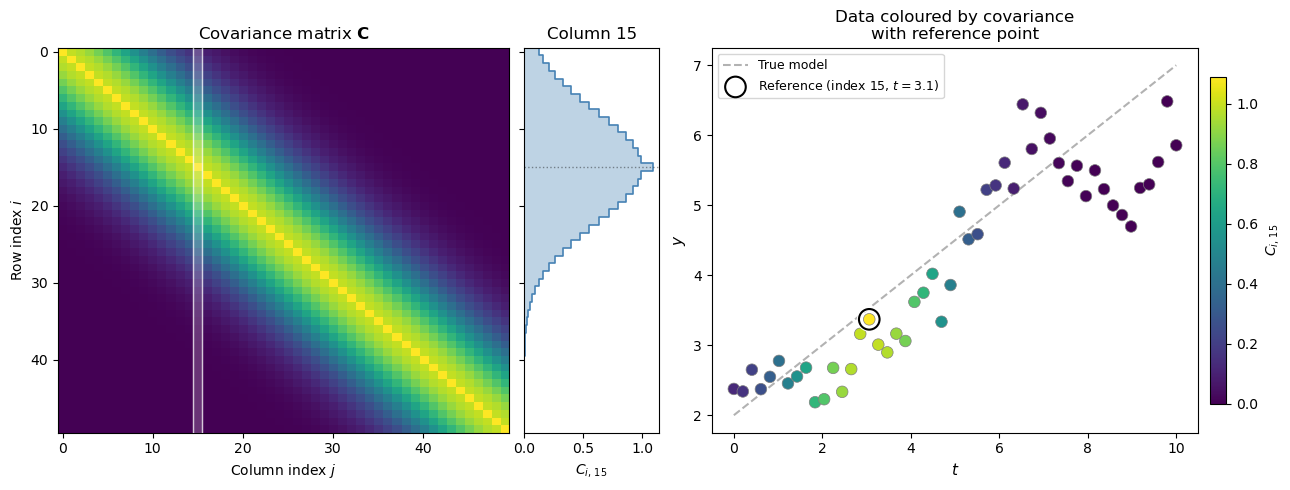

In [9]:
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 0.3, 0.05, 1.3], wspace=0.05)

ax_mat = fig.add_subplot(gs[0, 0])
ax_col = fig.add_subplot(gs[0, 1], sharey=ax_mat)
ax_data = fig.add_subplot(gs[0, 3])

# --- Left: covariance matrix with highlighted column ---
ax_mat.imshow(C, cmap='viridis', aspect='auto',
              extent=[-0.5, N-0.5, N-0.5, -0.5])
ax_mat.axvspan(ref - 0.5, ref + 0.5, color='white', alpha=0.2, zorder=2)
ax_mat.axvline(ref - 0.5, color='white', linewidth=1.0, alpha=0.7, zorder=3)
ax_mat.axvline(ref + 0.5, color='white', linewidth=1.0, alpha=0.7, zorder=3)
ax_mat.set_xlabel('Column index $j$')
ax_mat.set_ylabel('Row index $i$')
ax_mat.set_title(r'Covariance matrix $\mathbf{C}$', fontsize=12)

# --- Middle: column as horizontal step bars ---
indices = np.arange(N)
ax_col.barh(indices, cov_col, height=1.0, color='steelblue', alpha=0.35, edgecolor='none')
step_x = np.repeat(cov_col, 2)
step_y = np.empty(2 * N)
step_y[0::2] = indices - 0.5
step_y[1::2] = indices + 0.5
ax_col.plot(step_x, step_y, color='steelblue', lw=1.2)
ax_col.axhline(ref, color='black', ls=':', lw=1.0, alpha=0.4)
ax_col.set_xlabel(f'$C_{{i,\\,{ref}}}$', fontsize=10)
ax_col.set_title(f'Column {ref}', fontsize=12)
ax_col.tick_params(axis='y', labelleft=False)
ax_col.set_ylim(N - 0.5, -0.5)
ax_col.set_xlim(0, None)

# --- Right: data coloured by covariance with reference ---
ax_data.plot(t, true_model, 'k--', lw=1.5, alpha=0.3, label='True model')
sc = ax_data.scatter(t, data, c=cov_col, cmap='viridis', s=70,
                      edgecolors='grey', linewidths=0.5, zorder=3,
                      vmin=0, vmax=C.max())
ax_data.scatter(t[ref], data[ref], s=220, facecolors='none', edgecolors='white',
                linewidths=3, zorder=4)
ax_data.scatter(t[ref], data[ref], s=220, facecolors='none', edgecolors='black',
                linewidths=1.5, zorder=5,
                label=f'Reference (index {ref}, $t = {t[ref]:.1f}$)')
plt.colorbar(sc, ax=ax_data, label=f'$C_{{i,\\,{ref}}}$', shrink=0.85, pad=0.02)
ax_data.set_xlabel('$t$', fontsize=11)
ax_data.set_ylabel('$y$', fontsize=11)
ax_data.set_title('Data coloured by covariance\nwith reference point', fontsize=12)
ax_data.legend(fontsize=9, loc='upper left')

plt.show()

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

On the left is the matrix itself (bright = high covariance, dark = low), with axes showing the row and column indices. I've highlighted column 15 and extracted it in the middle panel. This shows the covariance of every data point with data point 15. On the right, I've coloured the actual data by this covariance. You can see that nearby points (bright yellow) are strongly correlated with the reference, while distant points (dark purple) are essentially independent. (Note that the matrix is symmetric, so the highlighted column is the same as row 15.)

The middle panel (one column of $\mathbf{C}$) is the kernel function $k(t_\text{ref},\, t_j)$ evaluated at every other point. This is what we will parameterise in the rest of this section.

Note that the colourbar exceeds 1 at the diagonal entry. This is because the covariance $C_{ij}$ is unbounded (it is not correlation).


</div>

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>2.2 Covariance across realisations</h2>

The above figure shows a single dataset. This dataset was a single draw from the multivariate Gaussian $\mathcal{N}(\mathbf{0},\, \mathbf{C})$. That is to say that the 50 noise values were drawn from a single 50-dimensional Gaussian whose covariance structure is given by $\mathbf{C}$. 

Also note for now that $\mathbf{C}$ tells you how those residuals are correlated with each other, and has nothing to do with the model itself. 

But $\mathbf{C}$ doesn't describe any single dataset. It describes the statistical relationships between data points across all possible datasets generated by this noise process. The entry $C_{ij} = \mathbb{E}[(x_i - \mu_i)(x_j - \mu_j)]$ is an expectation over the ensemble. It asks: if you repeated this experiment many times, how would the noise at point $i$ and the noise at point $j$ tend to co-vary?

To see this concretely, we below draw many noise realisations from the same $\mathbf{C}$ (without measurement noise) and watch how specific pairs of points behave. Below, we pick two partner points, one close to the reference (high covariance) and one far (low covariance). The close partner (orange) always scatters in the same direction as the reference (starred). The far partner (green) sometimes agrees, sometimes doesn't as it is essentially independent.

This is what $C_{ij}$ encodes, it just tells you how much information one point gives you about another.

</div>

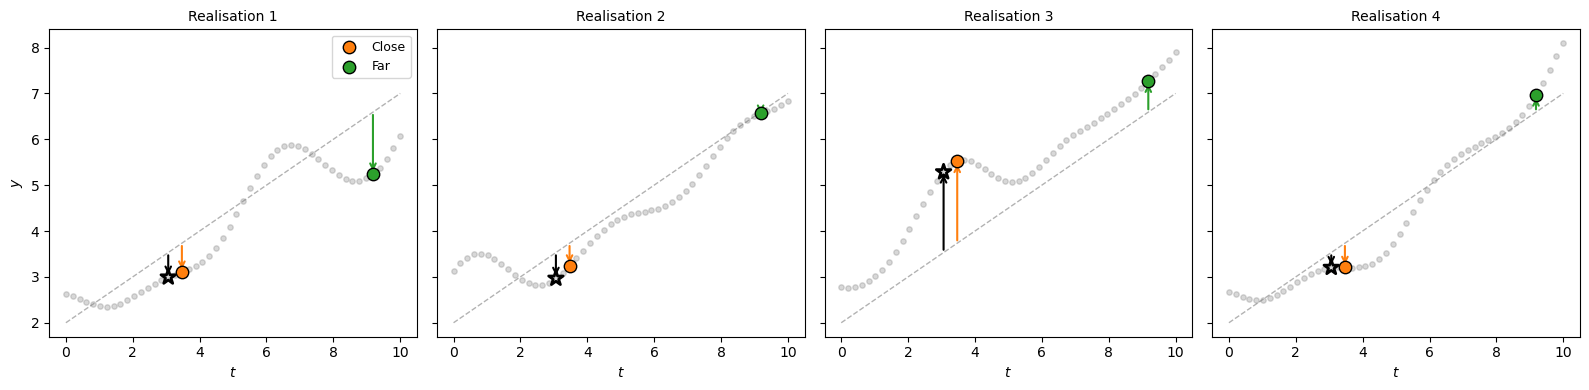

In [10]:
# === Multiple realisations: correlated vs independent partners ===
np.random.seed(42)

N = 50
t = np.linspace(0, 10, N)
true_model = 0.5 * t + 2.0

sigma = 1.0
ell = 1.5
C_true = sigma**2 * np.exp(-0.5 * ((t[:, None] - t[None, :]) / ell)**2)

ref = 15
close = 17   # nearby, high covariance
far = 45     # distant, near-zero covariance

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)

for col in range(4):
    ax = axes[col]
    noise = np.random.multivariate_normal(np.zeros(N), C_true)
    data = true_model + noise

    ax.plot(t, true_model, 'k--', lw=1, alpha=0.3)
    ax.scatter(t, data, c='grey', s=15, alpha=0.3, zorder=2)

    # Reference point
    ax.scatter(t[ref], data[ref], s=120, facecolors='none', edgecolors='black',
               linewidths=2, zorder=5, marker='*')

    # Close partner (orange)
    ax.scatter(t[close], data[close], s=80, c='tab:orange', edgecolors='black',
               linewidths=1, zorder=4, label='Close' if col == 0 else None)

    # Far partner (green)
    ax.scatter(t[far], data[far], s=80, c='tab:green', edgecolors='black',
               linewidths=1, zorder=4, label='Far' if col == 0 else None)

    # Arrows showing residuals
    for idx, c in [(ref, 'black'), (close, 'tab:orange'), (far, 'tab:green')]:
        ax.annotate('', xy=(t[idx], data[idx]), xytext=(t[idx], true_model[idx]),
                    arrowprops=dict(arrowstyle='->', color=c, lw=1.5))

    ax.set_title(f'Realisation {col + 1}', fontsize=10)
    ax.set_xlabel('$t$')

axes[0].set_ylabel('$y$')
axes[0].legend(fontsize=9)

plt.tight_layout()
plt.show()

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

------------

<h2>🏛️ Historical Aside: Predicting the Enemy</h2>

The mathematics of Gaussian processes were (sort of) invented during World War II, independently, by two mathematicians on the same side of the war, to solve the same problem: shooting down Nazi aircraft.

<h3>Norbert Wiener and the Anti-Aircraft Predictor</h3>

In September 1940, with London under the Blitz and a Nazi invasion looming, the American mathematician Norbert Wiener wrote to Vannevar Bush (head of the US National Defense Research Committee) offering his services. He was assigned a problem: how to aim anti-aircraft guns.

The difficulty was that by the time a shell reaches the altitude of a bomber, the aircraft has moved. You need to predict where the plane will be a few seconds into the future, based on noisy radar observations of where it has been. If the pilot flew in a straight line, this would be simple extrapolation. But pilots evade. They turn, climb, and dive unpredictably. 

Wiener's approach was to the pilot's evasive behaviour as a stationary stochastic process. Rather than trying to predict the pilot's intentions, he treated the trajectory as a random function with a known correlation structure. The philosopher of science Peter Galison has written about the conceptual implications of this move (<a href="https://monoskop.org/images/9/9c/Galison_Peter_1994_The_Ontology_of_the_Enemy_Norbert_Wiener_and_the_Cybernetic_Vision.pdf">"The Ontology of the Enemy"</a>, <i>Critical Inquiry</i>, 1994): by modelling the pilot as a stochastic process, Wiener erased the distinction between the human and the machine. The enemy became a statistical object, characterised entirely by its correlation structure. The correlations were limiting by things such as the planes maneuverability. The question was: given noisy observations of this random function up to time $t$, what is the best prediction of the function at time $t + \Delta$?

In the language of this notebook: Wiener had noisy observations $\mathbf{y}$ at input locations $\mathbf{X}$ (the radar measurements), and wanted to predict the function at a test point $x_*$ slightly in the future. Note that this is not "extrapolation" in the sense we talk about in §3.5. Wiener had continuous radar observations up to time $t$, and was predicting only a short interval $\Delta$ ahead, well within the correlation length of the process. The test point is close to the most recent data, so the kernel still provides strong covariance between the observations and the prediction. 

<h3>The Wiener-Hopf Equation</h3>

Wiener showed that the optimal linear predictor is a filter $h(\tau)$ that satisfies the Wiener-Hopf integral equation:

$$\int_0^\infty h(\tau)\, R_{yy}(t - \tau)\, d\tau = R_{ys}(t + \Delta) \qquad \text{for } t \geq 0$$

where $R_{yy}(t)$ is the autocovariance of the noisy observations and $R_{ys}(t)$ is the cross-covariance between the observations and the true signal. The constraint $\tau \geq 0$ enforces causality as the predictor can only use past and present observations, not future ones.

Compare this to the GP posterior mean from §3.4:

$$\bar{f}(x_*) = \sum_{i=1}^N \alpha_i\, k(x_*, x_i)$$

The structure is the same. The prediction is a weighted combination of the observations, where the weights are determined by the covariance structure. Wiener's autocovariance function $R_{yy}$ is our kernel $k$, and his cross-covariance $R_{ys}$ is our cross-covariance block $\mathbf{K}_{*f}$. The optimal predictor depends entirely on the autocovariance function, which is the kernel. Wiener derived GP regression in continuous time, 50 years before the machine learning community gave it that name.

In the language of §2, the kernel Wiener would have needed for the aircraft trajectory is something like a <b>Matérn-5/2</b> or <b>squared exponential</b>: the trajectory is smooth (aircraft can't teleport) but not periodic, with a length scale corresponding to the timescale of evasive manoeuvres (perhaps a few seconds). From the forces acting on the pilot and the plane, one could determine the differentiability requirement of the kernel function. The noise term $R_{yy} - R_{ss}$ corresponds to the radar measurement noise $\sigma_n^2$.

<h3>The Yellow Peril</h3>

Wiener wrote up his results in a classified report for the NDRC in February 1942. It ran to over 200 pages of dense mathematics, such as Fourier analysis, complex function theory, analytic continuation, and stationary stochastic processes. It was printed with a bright yellow cover. The engineers who were supposed to implement it called it the "Yellow Peril". Claude Shannon (of information theory fame), one of the few people who actually read the thing, reportedly described it as "ichthyological" (this may not be true, I can't find a primary source, also that word describes the study of fish, so I have no idea what Shannon meant).

The predictor was never built as a working weapon. Bell Labs, who were developing their own fire control systems, were not interested in a pure mathematician's stochastic process theory. The engineering was too far ahead of the electronics of the day. But the mathematics was sound, and the declassified version, published as a book in 1949, became foundational to signal processing, control theory, and eventually GP regression.

<h3>Kolmogorov: Similar Problem, the Same Maths</h3>

Meanwhile, in Moscow, Andrey Kolmogorov was working on the same problem. In 1941, with German forces approaching Moscow, Kolmogorov was tasked with applying statistical theory to artillery fire control and to the placement of barrage balloons over the city.

The barrage balloon problem is particularly interesting from a GP perspective. The balloons were tethered at various locations around Moscow, trailing steel cables to snag low-flying aircraft. The question was how should you distribute the balloons spatially to maximise the probability of intercepting incoming bombers? The bomber approach paths have spatial correlations (if one comes from the west, others probably will too, and they often fly in formation), and the problem is essentially a 2D spatial GP over Moscow's airspace, where the kernel encodes the spatial correlation structure of the attack patterns.

Kolmogorov independently derived the theory of optimal linear prediction for stationary processes, approaching it from the perspective of Hilbert space theory rather than Wiener's Fourier analysis. His papers on the subject (published in 1941) arrived at the same results through different mathematical machinery. Both men showed that the optimal predictor depends only on the autocovariance function of the process.

Neither knew of the other's work at the time. One was in Cambridge, the other in wartime Moscow. Both were fighting the same enemy's aircraft with the same mathematics. Neat. 

<h3>Anti-Aircraft Guns to Gaussian Processes</h3>

The Wiener-Kolmogorov prediction theory was the first formulation of what we now call Gaussian process regression, though the name came much later. The connection is that the autocovariance function that both men centred their theory on <i>is</i> the kernel. The optimal linear filter <i>is</i> the GP posterior mean. The prediction error variance <i>is</i> the GP posterior variance.

<h3>Two mathematicians, two responses</h3>

Norbert Wiener was a child prodigy who entered university at age 11 and received his PhD from Harvard at 18. He was absent-minded. One story (possibly apocryphal) has it that when his family moved house, his wife gave him written instructions with the new address. He lost the note during the day, returned to the old house out of habit, saw it was empty, and stopped a passing child to ask: "Excuse me, perhaps you know me. I'm Norbert Wiener and we've just moved. Do you know where we've moved to?" The child replied: "Yes, Daddy, Mummy sent me to get you." This story is probably not true.

After the war, Wiener became increasingly disturbed by the military applications of science. In January 1947, he published an open letter in <i>The Atlantic Monthly</i> titled <a href="https://www.cs.ucdavis.edu/~rogaway/classes/188/materials/wiener1.pdf">"A Scientist Rebels"</a>, in which he refused to share his research with Boeing for military purposes, writing: "I do not expect to publish any future work of mine which may do damage in the hands of irresponsible militarists." He also cut off contact with John von Neumann over the latter's enthusiasm for nuclear weapons development. The failed anti-aircraft predictor did, however, lead Wiener to something else entirely. Working on the predictor with the engineer Julian Bigelow, Wiener began thinking about purposeful behaviour in terms of negative feedback loops: systems that act to minimise the gap between a current state and an intended state. This line of thinking produced <i>Cybernetics</i> (1948) and founded the field that bears its name.

<hr style="border: none; border-top: 1px solid #ccc; margin: 20px 100px;">
<p style="text-align: left; font-style: italic; margin: 10px 60px;">
In the past, the comity of scholars has made it a custom to furnish scientific information to any person seriously seeking it. However, we must face these facts: the policy of the government itself during and after the war, say in the bombing of Hiroshima and Nagasaki, has made it clear that to provide scientific information is not a necessarily innocent act, and may entail the gravest consequences. One therefore cannot escape reconsidering the established custom of the scientist to give information to every person who may enquire of him. The interchange of ideas which is one of the great traditions of science must of course receive certain limitations when the scientist becomes an arbiter of life and death.
    <br><span style="font-style: normal; font-size: 0.9em;">— Norbert Wiener, <a href="https://www.cs.ucdavis.edu/~rogaway/classes/188/materials/wiener1.pdf">"A Scientist Rebels"</a>, <i>The Atlantic Monthly</i>, 1947</span>
</p>
<hr style="border: none; border-top: 1px solid #ccc; margin: 20px 100px;">

Kolmogorov's response to the post-war world was very different. Where Wiener publicly revolted against the military establishment, Kolmogorov remained embedded in the Soviet scientific system for his entire career, receiving seven Orders of Lenin and the title Hero of Socialist Labour. This contrast was perhaps not only a matter of temperament. Kolmogorov lived with the mathematician Pavel Aleksandrov for most of his adult life, in a relationship that was widely understood to be romantic. Homosexuality had been decriminalised after the 1917 revolution$^†$ but was recriminalised under Stalin in 1934. There is a credible theory that the threat of prosecution under Article 121 was used as leverage against Kolmogorov during the Luzin affair of 1936, when he was pressured into denouncing his former teacher Nikolai Luzin. A man in that position does not write open letters to <i>The Atlantic Monthly</i>.

$†$ *More precisely, the Bolsheviks abolished the entire Tsarist legal code after the 1917 revolution, and the new Soviet criminal code of 1922 simply did not include the old anti-sodomy statute. Homosexuality became legal by omission rather than by deliberate emancipation, though some early Soviet officials did cite this positively.*

-----------


</div>

In [11]:
# === Kernel helper functions ===
# We define each kernel and a plotting function here, then use them below.

def kernel_se(r, A, ell):
    """Squared exponential kernel."""
    return A**2 * np.exp(-0.5 * (r / ell)**2)

def kernel_matern12(r, A, ell):
    """Matérn-1/2 (exponential / Ornstein-Uhlenbeck)."""
    return A**2 * np.exp(-r / ell)

def kernel_matern32(r, A, ell):
    """Matérn-3/2."""
    s = np.sqrt(3) * r / ell
    return A**2 * (1 + s) * np.exp(-s)

def kernel_matern52(r, A, ell):
    """Matérn-5/2."""
    s = np.sqrt(5) * r / ell
    return A**2 * (1 + s + s**2 / 3) * np.exp(-s)

def kernel_periodic(r, A, ell, P):
    """Periodic kernel."""
    return A**2 * np.exp(-2 * np.sin(np.pi * r / P)**2 / ell**2)

def kernel_quasiperiodic(r, A, ell_p, P, ell_e):
    """Quasi-periodic kernel (periodic × SE envelope)."""
    return (A**2 
            * np.exp(-2 * np.sin(np.pi * r / P)**2 / ell_p**2) 
            * np.exp(-0.5 * (r / ell_e)**2))

In [12]:
def plot_kernel_demo(t, kernel_func, title, subtitle, n_samples=5, seed=42):
    """
    Two-panel plot: covariance matrix (left) and prior draws (right).
    
    Parameters
    ----------
    t : array, input locations
    kernel_func : callable, takes r = |x_i - x_j| and returns covariance
    title : str, kernel name for the covariance matrix title
    subtitle : str, hyperparameter values (LaTeX)
    n_samples : int, number of prior draws
    seed : int, random seed for reproducibility
    """
    np.random.seed(seed)
    N = len(t)
    r = np.abs(t[:, None] - t[None, :])
    K = kernel_func(r)
    K += 1e-10 * np.eye(N)  # jitter for numerical stability
    
    L = np.linalg.cholesky(K)
    samples = (L @ np.random.randn(N, n_samples)).T
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), 
                                    gridspec_kw={'width_ratios': [1, 1.3]})
    
    # Left: covariance matrix
    im = ax1.imshow(K, cmap='viridis', extent=[t[0], t[-1], t[-1], t[0]], aspect='auto')
    plt.colorbar(im, ax=ax1, shrink=0.85, label='Covariance')
    ax1.set_xlabel(r"$x'$")
    ax1.set_ylabel(r'$x$')
    ax1.set_title(f'Covariance matrix\n{title}', fontsize=11)
    
    # Right: prior draws
    colors = plt.cm.tab10(np.linspace(0, 1, n_samples))
    for i, s in enumerate(samples):
        ax2.plot(t, s, alpha=0.75, lw=1.2, color=colors[i])
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$f(x)$')
    ax2.set_title(f'Draws from $\\mathcal{{N}}(\\mathbf{{0}},\\, \\mathbf{{C}})$\n{subtitle}',
                  fontsize=11)
    ax2.axhline(0, color='k', lw=0.5, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>2.3 Squared Exponential (SE)</h2>

All the kernels we will see in this section depend only on the separation $r = |x - x'|$ between two points, not on their absolute positions. This property is called <b>stationarity</b>, and it means the correlation structure is translation-invariant: the process "looks the same" everywhere. This is a reasonable assumption when the noise properties don't change across your dataset (e.g. instrumental systematics that behave the same way throughout an observation), but not always (e.g. a signal whose character changes over time). Non-stationary kernels exist but are beyond this tutorial.

The simplest and most commonly used stationary kernel is the squared exponential:

$$k_\text{SE}(r) = A^2 \exp\!\left(-\frac{r^2}{2\ell^2}\right)$$

where $r = |x - x'|$.

This is a Gaussian function of the separation. Its key property is that functions drawn from a GP with an SE kernel are infinitely differentiable. This makes the SE kernel very convenient mathematically, but it is also a potential weakness. Real physical processes are not always infinitely smooth. The SE kernel tends to produce unrealistically confident predictions in data gaps, because it "knows" the function can't do anything sudden. If you have reason to believe the underlying signal is very smooth (e.g. a slowly varying instrumental response), the SE is a good choice. If not, the Matérn family (below) is usually more appropriate.

Despite this caveat, the SE is a good starting point and you will see it everywhere.

Below is an example of the squared exponential kernel. On the left is the covariance matrix, on the right are some draws from the matrix. Play around with the hyperparameters ```A``` and ```ell```:

</div>

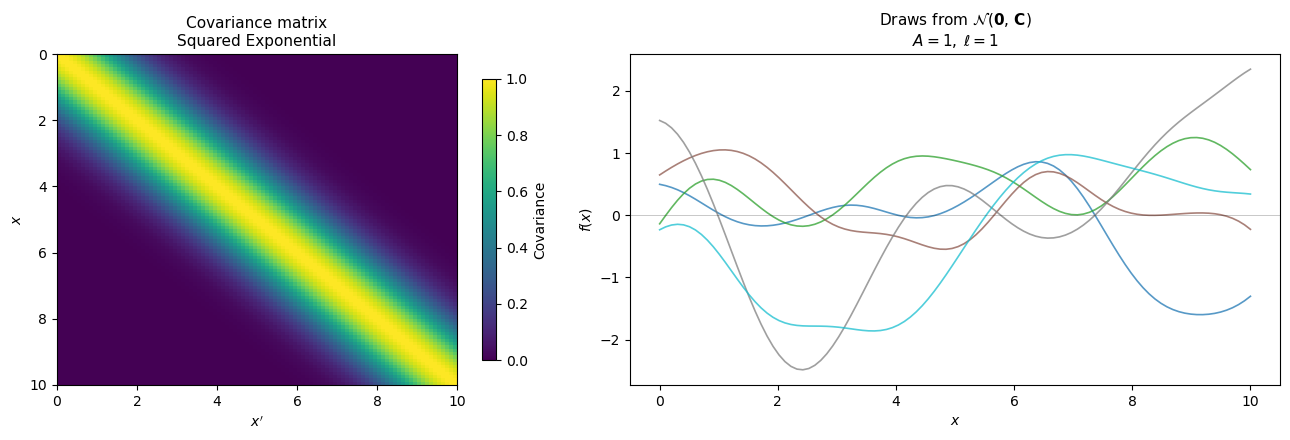

In [13]:
# --- Squared exponential: covariance matrix + prior draws ---
t_demo = np.linspace(0, 10, 100)

plot_kernel_demo(
    t_demo,
    kernel_func=lambda r: kernel_se(r, A=1.0, ell=1.2),
    title='Squared Exponential',
    subtitle=r'$A = 1,\;\ell = 1$'
)

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>2.4 The Matérn family</h2>

If the SE kernel is too smooth, we want a way to control the smoothness. The Matérn family does exactly this with a single additional parameter $\nu$ that sets the differentiability of the sample functions: a draw from a Matérn-$\nu$ GP is $\lceil \nu \rceil - 1$ times mean-square differentiable.

The general form involves the modified Bessel function $K_\nu$:

$$k_\nu(r) = A^2 \frac{2^{1-\nu}}{\Gamma(\nu)}\left(\frac{\sqrt{2\nu}\,r}{\ell}\right)^\nu K_\nu\!\left(\frac{\sqrt{2\nu}\,r}{\ell}\right)$$

You do not need to remember this. In practice, only three special values of $\nu$ are used, and they have clean closed forms.

<h3>Matérn-1/2 (exponential / Ornstein-Uhlenbeck)</h3>

$$k_{1/2}(r) = A^2 \exp\!\left(-\frac{r}{\ell}\right)$$

Continuous but <b>nowhere differentiable</b>. Produces rough, jagged sample paths. This is the covariance function of a damped random walk, which is the standard model for quasar optical variability (Kelly et al. 2009, Kozłowski et al. 2010). Note that this differs from the SE only in the exponent: $r$ instead of $r^2$. 

<h3>Matérn-3/2</h3>

$$k_{3/2}(r) = A^2\left(1 + \frac{\sqrt{3}\,r}{\ell}\right)\exp\!\left(-\frac{\sqrt{3}\,r}{\ell}\right)$$

<b>Once differentiable.</b> A good default for many astronomical time series: smooth enough to be physical, rough enough not to overfit gaps. This is the kernel used by Gibson et al. (2012) in the HD 189733b reanalysis from §1.5.

<h3>Matérn-5/2</h3>

$$k_{5/2}(r) = A^2\left(1 + \frac{\sqrt{5}\,r}{\ell} + \frac{5r^2}{3\ell^2}\right)\exp\!\left(-\frac{\sqrt{5}\,r}{\ell}\right)$$

<b>Twice differentiable.</b>  This is also the kernel used in the sausage plot in §0.

As $\nu \to \infty$, the Matérn converges to the SE. The squared exponential is the limiting case of "infinite smoothness," and usually an unrealistic one.

</div>

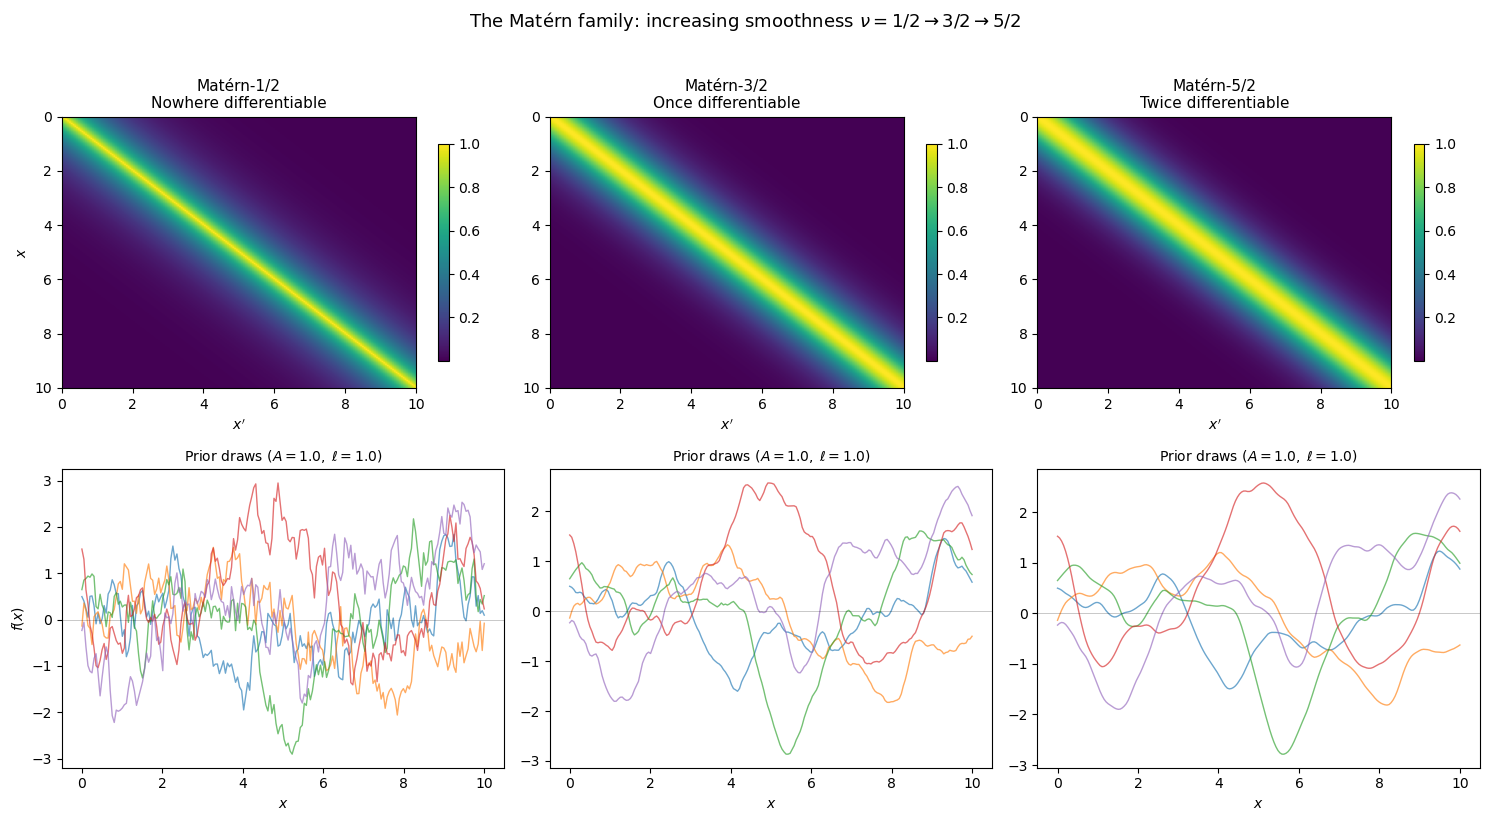

In [14]:
# --- Matérn family: three smoothness levels side by side ---
t_demo = np.linspace(0, 10, 200)
np.random.seed(42)

# Use the SAME random vectors for all three so the differences are purely from the kernel
N = len(t_demo)
z = np.random.randn(N, 5)

fig, axes = plt.subplots(2, 3, figsize=(15, 8),
                         gridspec_kw={'height_ratios': [1, 1.1]})

matern_kernels = [
    (kernel_matern12, r'Matérn-1/2', r'Nowhere differentiable'),
    (kernel_matern32, r'Matérn-3/2', r'Once differentiable'),
    (kernel_matern52, r'Matérn-5/2', r'Twice differentiable'),
]

A, ell = 1.0, 1.0

for col, (kfunc, name, smooth) in enumerate(matern_kernels):
    r = np.abs(t_demo[:, None] - t_demo[None, :])
    K = kfunc(r, A, ell) + 1e-10 * np.eye(N)
    L = np.linalg.cholesky(K)
    samples = (L @ z).T
    
    # Top row: covariance matrix
    im = axes[0, col].imshow(K, cmap='viridis', 
                              extent=[t_demo[0], t_demo[-1], t_demo[-1], t_demo[0]],
                              aspect='auto')
    plt.colorbar(im, ax=axes[0, col], shrink=0.8)
    axes[0, col].set_title(f'{name}\n{smooth}', fontsize=11)
    axes[0, col].set_xlabel(r"$x'$")
    if col == 0:
        axes[0, col].set_ylabel('$x$')
    
    # Bottom row: prior draws
    for s in samples:
        axes[1, col].plot(t_demo, s, alpha=0.65, lw=1.0)
    axes[1, col].axhline(0, color='k', lw=0.5, alpha=0.3)
    axes[1, col].set_xlabel('$x$')
    if col == 0:
        axes[1, col].set_ylabel('$f(x)$')
    axes[1, col].set_title(f'Prior draws ($A = {A},\\; \\ell = {ell}$)', fontsize=10)

plt.suptitle(r'The Matérn family: increasing smoothness $\nu = 1/2 \to 3/2 \to 5/2$',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>2.5 Periodic kernel</h2>

$$k_\text{per}(r) = A^2 \exp\!\left(-\frac{2\sin^2(\pi r / P)}{\ell^2}\right)$$

This produces <b>exactly periodic</b> functions with period $P$. The $\sin^2$ maps the separation onto a circle before applying an SE-like exponential decay, so the kernel "wraps around" every $P$. The length scale $\ell$ controls the smoothness <i>within</i> each period: small $\ell$ gives complex, wiggly periods; large $\ell$ gives smooth, nearly sinusoidal periods.

You would use this for a signal with a known, stable periodicity (e.g. a binary orbit, a pulsation mode). But most real astronomical periodicities are not exactly periodic: starspots appear, evolve, and decay; a planet's transit depth varies with stellar activity; an RV signal is modulated by changing spot coverage. For these, you usually need something more flexible.

</div>

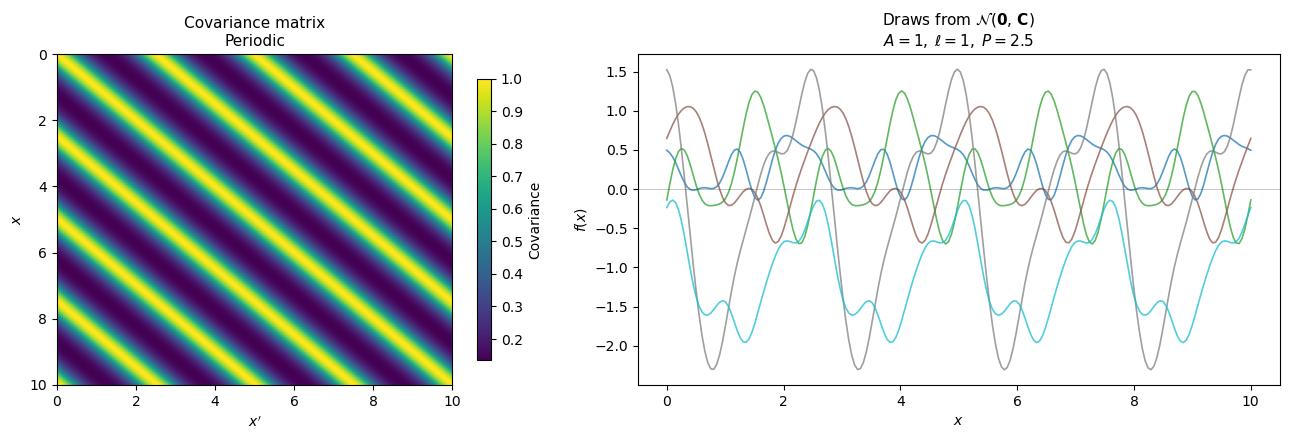

In [15]:
# --- Periodic kernel: covariance matrix + prior draws ---
t_demo = np.linspace(0, 10, 200)

plot_kernel_demo(
    t_demo,
    kernel_func=lambda r: kernel_periodic(r, A=1.0, ell=1.0, P=2.5),
    title='Periodic',
    subtitle=r'$A = 1,\;\ell = 1,\; P = 2.5$'
)

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>2.6 Quasi-periodic kernel and kernel algebra</h2>

The periodic kernel produces functions that repeat identically forever. But stellar rotation, for instance, produces a signal that repeats with a stable period $P_\text{rot}$ while the pattern itself evolves as spots form and decay. We want periodicity that can decorrelate over time.

We can build this by <b>multiplying</b> the periodic kernel by an SE kernel:

$$k_\text{QP}(r) = A^2 \exp\!\left(-\frac{2\sin^2(\pi r / P)}{\ell_p^2}\right) \exp\!\left(-\frac{r^2}{2\ell_e^2}\right)$$

The periodic factor gives the repeating structure. The SE factor acts as an <i>envelope</i> that makes distant repetitions decorrelate, with a characteristic evolution timescale $\ell_e$. At separations $\ll \ell_e$, the signal repeats faithfully; at separations $\gg \ell_e$, the repetitions have forgotten each other. This is a very common kernel in exoplanet science.

<h3>Kernel algebra</h3>

The quasi-periodic kernel is our first example of <b>combining kernels</b>. This turns out to be very general:

<ul>
<li><b>Product</b>: $k_1 \times k_2$ produces functions with <i>both</i> properties simultaneously. The QP kernel is periodic $\times$ SE: periodicity that decays.</li>
<li><b>Sum</b>: $k_1 + k_2$ models <i>independent additive</i> components. For example, a long-term instrumental trend (SE with large $\ell$) + stellar rotation (QP) + uncorrelated measurement noise (white noise).</li>
</ul>

<b>Scalar multiplication</b>: $c \cdot k$ for $c > 0$ rescales the amplitude. We have been doing this already every time we write $A^2 \cdot k$.

A key mathematical fact: any sum or product of valid kernels is itself a valid kernel. That is, the resulting $\mathbf{C}$ is guaranteed to be positive-definite. This means you can freely compose kernels to build complex correlation structures from simple building blocks, without worrying about whether the result is a legitimate covariance matrix.

<h3>Rational quadratic kernel</h3>

There is one more kernel worth mentioning. The <b>rational quadratic</b> (RQ) kernel:

$$k_\text{RQ}(r) = A^2 \left(1 + \frac{r^2}{2\alpha\ell^2}\right)^{-\alpha}$$

can be shown to be equivalent to an infinite sum of SE kernels with different length scales. The parameter $\alpha$ controls how much the length scales vary: as $\alpha \to \infty$, the RQ converges to the SE. The RQ is useful when the data has structure at multiple scales simultaneously, and you don't want to commit to a single length scale. We will see it used in the Mauna Loa CO₂ example in §5.

</div>

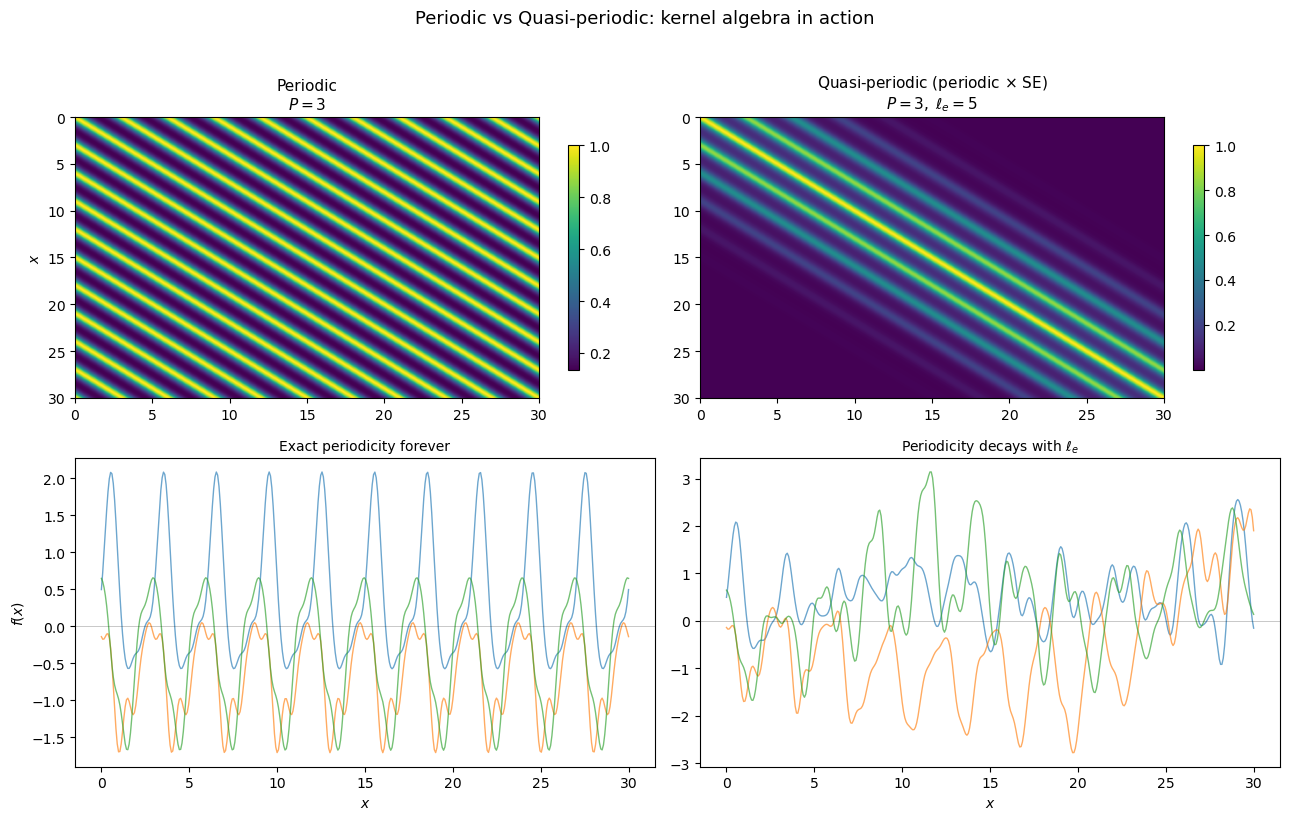

In [16]:
# --- Quasi-periodic kernel: covariance matrix + prior draws ---
# Also show the periodic kernel alone for comparison
t_demo = np.linspace(0, 30, 400)  # longer baseline to see the decay

np.random.seed(42)
N = len(t_demo)
z = np.random.randn(N, 3)

fig, axes = plt.subplots(2, 2, figsize=(13, 8),
                         gridspec_kw={'height_ratios': [1, 1.1]})

r = np.abs(t_demo[:, None] - t_demo[None, :])

# Left: periodic
K_per = kernel_periodic(r, A=1.0, ell=1.0, P=3.0) + 1e-10 * np.eye(N)
L_per = np.linalg.cholesky(K_per)
samples_per = (L_per @ z).T

im0 = axes[0, 0].imshow(K_per, cmap='viridis',
                          extent=[t_demo[0], t_demo[-1], t_demo[-1], t_demo[0]], aspect='auto')
plt.colorbar(im0, ax=axes[0, 0], shrink=0.8)
axes[0, 0].set_title('Periodic\n$P = 3$', fontsize=11)
axes[0, 0].set_ylabel('$x$')

for s in samples_per:
    axes[1, 0].plot(t_demo, s, alpha=0.65, lw=1.0)
axes[1, 0].axhline(0, color='k', lw=0.5, alpha=0.3)
axes[1, 0].set_xlabel('$x$')
axes[1, 0].set_ylabel('$f(x)$')
axes[1, 0].set_title(r'Exact periodicity forever', fontsize=10)

# Right: quasi-periodic
K_qp = kernel_quasiperiodic(r, A=1.0, ell_p=1.0, P=3.0, ell_e=5.0) + 1e-10 * np.eye(N)
L_qp = np.linalg.cholesky(K_qp)
samples_qp = (L_qp @ z).T

im1 = axes[0, 1].imshow(K_qp, cmap='viridis',
                          extent=[t_demo[0], t_demo[-1], t_demo[-1], t_demo[0]], aspect='auto')
plt.colorbar(im1, ax=axes[0, 1], shrink=0.8)
axes[0, 1].set_title('Quasi-periodic (periodic $\\times$ SE)\n$P = 3,\\; \\ell_e = 5$', fontsize=11)

for s in samples_qp:
    axes[1, 1].plot(t_demo, s, alpha=0.65, lw=1.0)
axes[1, 1].axhline(0, color='k', lw=0.5, alpha=0.3)
axes[1, 1].set_xlabel('$x$')
axes[1, 1].set_title(r'Periodicity decays with $\ell_e$', fontsize=10)

plt.suptitle('Periodic vs Quasi-periodic: kernel algebra in action',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>2.7 White noise kernel</h2>

$$k_\text{wn}(x, x') = \sigma_n^2\,\delta(x, x')$$

This adds $\sigma_n^2$ to the diagonal of $\mathbf{C}$ only. It represents uncorrelated measurement noise: each data point has its own independent scatter, with no correlation between points.

You will almost always include this as a component of your total kernel: $k_\text{total} = k_\text{signal} + k_\text{wn}$. Without it, the GP tries to pass exactly through every data point, treating all scatter as signal. With real (noisy) data, this is almost never what you want.

Note: in <code>tinygp</code>, white noise is handled via the <code>diag</code> argument rather than as a kernel object. Some other GP libraries (e.g. <code>george</code>, <code>GPy</code>) include it as a <code>WhiteKernel</code>. Same thing.

</div>

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>2.8 Summary</h2>

The kernel function $k(x, x')$ is the heart of a Gaussian process. It determines every entry of the covariance matrix $\mathbf{C}$, and through $\mathbf{C}$, it controls what kinds of functions the GP considers plausible. We have seen:

<ul>
<li>The <b>SE kernel</b> produces infinitely smooth functions, mathematically convenient but often unrealistically smooth.</li>
<li>The <b>Matérn family</b> provides controlled smoothness via $\nu$. Matérn-3/2 and 5/2 are the most commonly used kernels in astronomy.</li>
<li>The <b>periodic kernel</b> produces exactly repeating functions.</li>
<li>The <b>quasi-periodic kernel</b> (periodic $\times$ SE) produces evolving periodic signals. It is the standard model for stellar rotation.</li>
<li>The <b>white noise kernel</b> adds uncorrelated measurement noise to the diagonal.</li>
<li>Kernels can be freely combined via sums (independent additive components) and products (joint properties).</li>
</ul>

Although all our examples so far have used time as the input, nothing in the GP framework requires this. The input $x$ can be wavelength (for spectral fitting), spatial position (for sky subtraction), metallicity (for interpolating stellar models), or any continuous variable. For example, in spectral analysis, you might use a GP to model the continuum as a smooth function of wavelength, with absorption or emission lines captured by a parametric mean function. The kernel would encode your assumption about how smooth the continuum is (an SE or Matérn kernel with a length scale of tens of Ångströms, say). The maths is identical.


</div>

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>2.9 Multi-dimensional inputs and 2D GPs</h2>

Everything we have derived works identically when the input is a vector $\mathbf{x} \in \mathbb{R}^D$ rather than a scalar $x \in \mathbb{R}$. The kernel just takes two input vectors and returns a scalar covariance. For isotropic stationary kernels, the separation becomes $r = ||\mathbf{x} - \mathbf{x}'||$ instead of $|x - x'|$.

For example, the SE kernel in 2D is:

$$k(\mathbf{x}, \mathbf{x}') = A^2 \exp\left(-\frac{(x_1 - x_1')^2}{2\ell_1^2} - \frac{(x_2 - x_2')^2}{2\ell_2^2}\right)$$

With $\ell_1 = \ell_2$, this is isotropic as the covariance depends only on the Euclidean distance, and the correlation structure looks the same in every direction (circular contours). With $\ell_1 \neq \ell_2$, the kernel is anisotropic as correlations decay faster in one direction than the other (elliptical contours). 

More generally, you can use a separate length scale per input dimension: $r = \sqrt{\sum_d (x_d - x_d')^2 / \ell_d^2}$. Each $\ell_d$ controls how relevant that dimension is. If the data says $\ell_d \to \infty$ for some dimension $d$, that dimension is irrelevant and the GP effectively ignores it. This is called Automatic Relevance Determination (ARD), and it is  what Gibson et al. used in the HD 189733b reanalysis from §1.5: a separate length scale per auxiliary variable (detector position, temperature, etc.), so the GP could automatically determine which variables mattered.

Below, we draw samples from a 2D GP on a grid, with an isotropic SE kernel (left) and an anisotropic one (right):

</div>

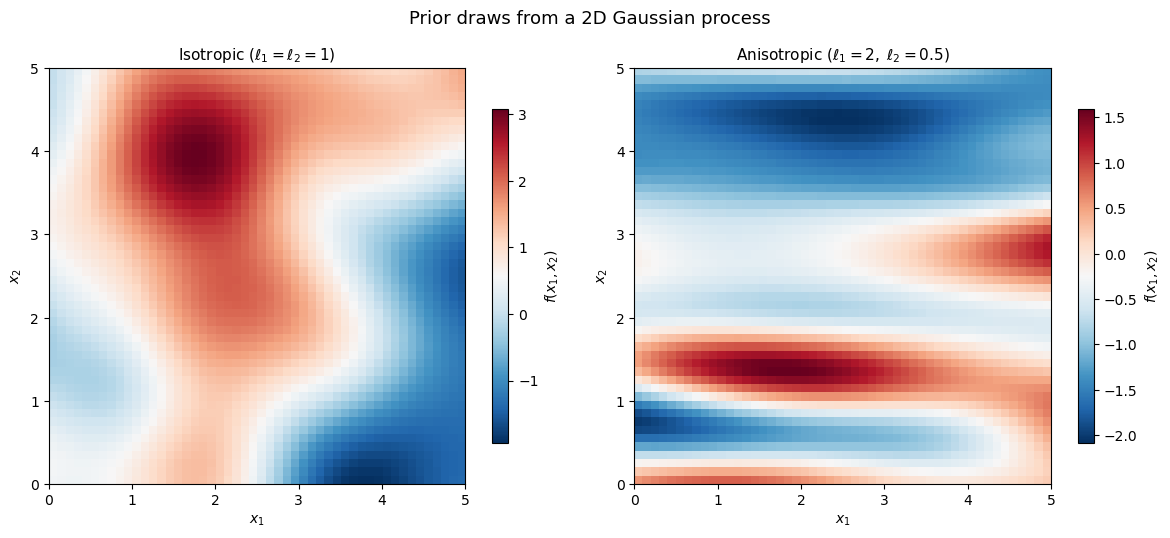

In [17]:
# === 2D GP prior draws ===
np.random.seed(42)

# Create a 2D grid
n_grid = 50
x1 = np.linspace(0, 5, n_grid)
x2 = np.linspace(0, 5, n_grid)
X1, X2 = np.meshgrid(x1, x2)
X_flat = np.column_stack([X1.ravel(), X2.ravel()])
N_2d = len(X_flat)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, ell1, ell2, title in [
    (axes[0], 1.0, 1.0, r'Isotropic ($\ell_1 = \ell_2 = 1$)'),
    (axes[1], 2.0, 0.5, r'Anisotropic ($\ell_1 = 2,\; \ell_2 = 0.5$)')
]:
    # Build 2D SE kernel matrix
    dx1 = (X_flat[:, 0:1] - X_flat[:, 0:1].T) / ell1
    dx2 = (X_flat[:, 1:2] - X_flat[:, 1:2].T) / ell2
    K = np.exp(-0.5 * (dx1**2 + dx2**2)) + 1e-8 * np.eye(N_2d)
    
    # Draw one sample
    L = np.linalg.cholesky(K)
    sample = L @ np.random.randn(N_2d)
    
    im = ax.imshow(sample.reshape(n_grid, n_grid), extent=[0, 5, 0, 5],
                    origin='lower', cmap='RdBu_r', aspect='equal')
    plt.colorbar(im, ax=ax, shrink=0.8, label='$f(x_1, x_2)$')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(title, fontsize=11)

plt.suptitle('Prior draws from a 2D Gaussian process', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

The isotropic sample (left) has no preferred direction: the "blobs" of positive and negative values are roughly circular. The anisotropic sample (right) is elongated along $x_1$ (the direction with the longer length scale) and varies rapidly along $x_2$. This is a single draw from the prior. A 2D GP conditioned on observations would produce a smooth interpolation of the data across the image, with uncertainty that grows in regions far from observations.

2D GPs are used in astronomy for sky subtraction (the background varies smoothly across the detector), PSF interpolation (the PSF shape varies smoothly across the field of view), and low surface brightness imaging (separating smooth large-scale structure from noise).

One practical concern: for a $100 \times 100$ image, $N = 10{,}000$, and the covariance matrix is $10{,}000 \times 10{,}000$. This is where the $\mathcal{O}(N^3)$ cost from §6 really bites. However, for GPs on regular grids, there is a significant computational shortcut. If the kernel is separable across dimensions (such as the anisotropic SE above), the covariance matrix factors as a Kronecker product of smaller matrices, one per dimension. For a $100 \times 100$ grid, this reduces the cost from decomposing a $10{,}000 \times 10{,}000$ matrix to decomposing two $100 \times 100$ matrices. For more on Kronecker-structured GPs and other scalable methods, see <a href="https://mlg.eng.cam.ac.uk/pub/pdf/Saa11.pdf">Saatçi (2011)</a> and Aigrain &amp; Foreman-Mackey (2023) §5.1.

In the during-tutorial, we may apply a 2D GP to real imaging data.

------------

</div>

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h1>§3. GP Regression: Prior to Posterior</h1>

Everything in §2 was <i>prior</i>: functions drawn from $\mathcal{N}(\mathbf{0},\, \mathbf{C})$ before seeing any data. In this section, we condition on observations to obtain the posterior distribution over functions.

<h2>3.1 The mean function</h2>

Before we derive anything, we need to mention the <b>mean function</b> $m(x)$.

A GP is fully specified by two things: a mean function $m(x)$ and a kernel $k(x, x')$:

$$f \sim \mathcal{GP}\big(m(x),\; k(x, x')\big)$$

This says: the function $f$ is drawn from a Gaussian process whose prior mean at any input $x$ is $m(x)$, and whose covariance between any two inputs is $k(x, x')$. Everything we did in §2 used $m(x) = 0$, which is why our prior draws oscillated around zero.

In practice, there are two common approaches:

<ul>
<li>Set $m(x) = 0$ and let the GP do everything. This is what most tutorials do. It works well when the function you're modelling has no known parametric form, and the GP is capturing the entire signal. The sausage plot in §0 was an example of this.</li>
<li>Set $m(x)$ to a physical model and let the GP handle the residuals. This is more common in astronomy. You have a transit model, an RV curve, or a spectral template, and the GP captures the correlated noise or stellar variability on top of the model. In this case, the GP is not replacing your physics, it is just modelling the nuisance signal that your physics doesn't capture.</li>
</ul>

In the second approach, $\mathbf{C}$ describes the correlations in the <i>residuals</i> between the data and the model, which is what we set up in §1. 

For the derivations that follow, we will use $m(x) = 0$ to keep things clean. Everything generalises straightforwardly by replacing $\mathbf{y}$ with $\mathbf{y} - \mathbf{m}$ (the residuals).

</div>

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>3.2 The problem</h2>

We have $N$ observations: data values $\mathbf{y} = (y_1, \ldots, y_N)$ measured at input locations $\mathbf{X} = (x_1, \ldots, x_N)$. Each observation is the true function value plus noise, i.e. $y_i = f(x_i) + \epsilon_i$. This is the data we have at the times we have measured something. But we would like to know things about the times we haven't measured something (i.e. infer something). That is to say, that we chose $N_*$ new locations $\mathbf{X}_*$ (the test points), where we have no data, and we want to infer the function values  best estimate of the function $f$ at those locations, and the uncertainty on that estimate.

In practice, these test points are usually a dense grid spanning (and sometimes slightly beyond) the range of the measured data. These test points are what produced the sausage plot from the start. We write the unknown function values at the test point as:

$$\mathbf{f}_* = (f(x_*^{(1)}), \ldots, f(x_*^{(N_*)}))$$

*I don't like this notation, but it is unfortunately standard.*

So the question is: given the observations $\mathbf{y}$, what can we say about the test points $\mathbf{f}_*$?

To answer this, we need to know how the observations and the test points are related to each other. Think about a single test point $x_*$ that sits between two observations. The kernel tells us how correlated $x_*$ is with each of those observations. If the kernel says "strongly correlated," then knowing what the observations are tells us a lot about what $f(x_*)$ should be. If the kernel says "weakly correlated," the observations are less informative and we remain uncertain, which is what the sausage plot showed us. This is why we need to build a covariance matrix that includes both the observed and test points (below). The entries connecting observed points to test points (the cross-covariances) are the mechanism by which data constrains predictions. Without them, the test points would have no way of learning anything from the observations.

<h2>3.3 Building the joint covariance matrix</h2>

In  §2, we built the covariance matrix $\mathbf{C}$ for the $N$ observed points. This was an $N\times N$ matrix where every entry $C_{ij} = k(x_i, x_j)$ was determined by the kernel. We can do the same thing for any set of input locations, there is nothing special (in the $\mathbf{C}$ matrix) about the ones where we happened to collect data. The kernel is just a function of two inputs. If we hand it two input locations, it returns a covariance. 

<details class="alert alert-info" style="margin: 10px 0;">
<summary style="cursor: pointer; font-weight: bold;">If the kernel treats observed and test points identically, how does the GP know which values are constrained by data?</summary>
<div style="margin-top: 10px;">

It doesn't yet. The joint covariance matrix is purely prior: it encodes the correlation structure we assumed through the kernel, before looking at any data. The data enter in the next step, when we <b>condition</b>: we fix the observed values to what we actually measured, and ask what the remaining (test) values must look like given those observations.

</div>
</details>

So if we take all of points together, the measured and the test, we have a total of $N+N_*$ points together. We can build a single, larger covariance matrix of shape $(N+N_*) \times (N+N_*)$, and every entry is still just the kernel evaluated at the corresponding pair of inputs.

$$C_{ij} = k(x_i, x_j) \quad \text{for all } i, j \in \{1, \ldots, N + N_*\}$$

If we group the observed points first (indices $1, \ldots, N$) and the test points second (indices $N+1, \ldots, N+N_*$), the matrix naturally splits into four, notationally convenient blocks. Suppose we have $N=3$ observed points and $N_* = 2$ test points, the full $5\times 5$ covariance matrix is (*and I apologise for the notation jumpscare*):

$$\left(\begin{array}{ccc|cc} k(x_1, x_1) & k(x_1, x_2) & k(x_1, x_3) & k(x_1, x_*^{(1)}) & k(x_1, x_*^{(2)}) \\ k(x_2, x_1) & k(x_2, x_2) & k(x_2, x_3) & k(x_2, x_*^{(1)}) & k(x_2, x_*^{(2)}) \\ k(x_3, x_1) & k(x_3, x_2) & k(x_3, x_3) & k(x_3, x_*^{(1)}) & k(x_3, x_*^{(2)}) \\ \hline k(x_*^{(1)}, x_1) & k(x_*^{(1)}, x_2) & k(x_*^{(1)}, x_3) & k(x_*^{(1)}, x_*^{(1)}) & k(x_*^{(1)}, x_*^{(2)}) \\ k(x_*^{(2)}, x_1) & k(x_*^{(2)}, x_2) & k(x_*^{(2)}, x_3) & k(x_*^{(2)}, x_*^{(1)}) & k(x_*^{(2)}, x_*^{(2)}) \end{array}\right)$$

Here, the solid lines are just visual guides, and remember that  $k(x_i, x_j)$ is just the covariance between two points. The four blocks are:

- Top left ($3\times 3$): Denoted $\mathbf{K}_{ff}$, the covariance between the observed points. This is what $\mathbf{C}$ has referred to so far.
- Top right ($3\times 2$): Denoted $\mathbf{K}_{f*}$, the (cross)-covariance between observed and test points.
- Bottom left ($2\times 3$): Denoted $\mathbf{K}_{*f}$, the transpose of the top right block (because $k(x, x') = k(x', x)$).
- Bottom right ($2\times 2$): Denoted $\mathbf{K}_{**}$, the covariance between test points.

With this new notation, we can write the above matrix as:

$$\left(\begin{array}{c|c} \mathbf{K}_{ff} & \mathbf{K}_{f*} \\ \hline \mathbf{K}_{*f} & \mathbf{K}_{**} \end{array}\right)$$

<details class="alert alert-info" style="margin: 10px 0;">
<summary style="cursor: pointer; font-weight: bold;">Shouldn't we order by time of observation?</summary>
<div style="margin-top: 10px;">

Physically, these points might be interleaved in time. But the covariance between two points depends only on their input locations through the kernel, not on the order we happen to list them. So we are free to rearrange the rows and columns of the matrix without changing any of the covariance values. This rearrangement lets us write the matrix in a block form that makes the conditioning formula compact.
</div>
</details>

There is one more step. For our observed points, we have measurement uncertainty. This is the uncorrelated part, and it only affects the observed points, the test points are "noise-free". So we need to add $\sigma_n^2$ to the top left block only:

$$\left(\begin{array}{cc} \mathbf{K}_{ff}+\sigma_n^2 \mathbf{I} & \mathbf{K}_{f*} \\ \mathbf{K}_{*f} & \mathbf{K}_{**} \end{array}\right)$$

We can now write out list of observations as (assuming a mean model of 0, i.e. we are just looking at residuals):

$$\begin{pmatrix} \mathbf{y} \\ \mathbf{f}_* \end{pmatrix} \sim \mathcal{N}\!\left( \mathbf{0},\; \begin{pmatrix} \mathbf{K}_{ff} + \sigma_n^2 \mathbf{I} & \mathbf{K}_{f*} \\ \mathbf{K}_{*f} & \mathbf{K}_{**} \end{pmatrix} \right)$$

This is the joint prior distribution over the observed data and the predictions. It is a single multivariate Gaussian over all $N + N_*$ values.

The question "what is $\mathbf{f}_*$ given $\mathbf{y}$?" is now a standard problem: we have a joint Gaussian, we observe some of the variables, and we want the conditional distribution of the rest.

</div>

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>3.4 Conditioning: from joint to posterior</h2>

We have a joint Gaussian distribution over the observed values $\mathbf{y}$ and the test values $\mathbf{f}_*$, and we want to know: what is the distribution of $\mathbf{f}_*$ given that we have observed $\mathbf{y}$? This is conditioning, and it is what Bayes' theorem does. In the Bayes 101 tutorial, we wrote:

$$P(\theta \mid D) \propto P(D \mid \theta)\, P(\theta)$$

Here, the "parameters" are the function values $\mathbf{f}_*$ at the test points, the "data" are the observations $\mathbf{y}$, the "prior" is the GP prior encoded in the kernel, and the "posterior" is the conditional distribution $\mathbf{f}_* \mid \mathbf{y}$. The only difference from what we did before is that both the prior and the likelihood are Gaussian, which means the posterior is also Gaussian.

<h3>Recall: the 2D case</h3>

We have already seen conditioning in §1.4, in the 2D worked example with the error ellipse. There, we had two correlated variables $(r_1, r_2)$ with a joint Gaussian distribution. The off-diagonal entry of the covariance matrix told us how they were related. If you learned that $r_1$ had scattered high, the distribution of $r_2$ shifted (its mean moved toward the observed value, weighted by the correlation) and narrowed (its variance decreased, because you gained information). If $r_1$ and $r_2$ were strongly correlated, the shift was large and the narrowing was significant. If they were weakly correlated, $r_2$ barely changed.

What we are about to do is the same thing, just in $N + N_*$ dimensions instead of two. We know the values of some variables (the observations $\mathbf{y}$), and we want the conditional distribution of the rest (the test values $\mathbf{f}_*$). The cross-covariance blocks $\mathbf{K}_{f*}$ play the same role as the off-diagonal entry in the 2D case: they determine how much the observations shift and constrain the predictions.

<h3>The conditioning formula</h3>

For a multivariate Gaussian, conditioning always produces another multivariate Gaussian. That is, if you take a joint Gaussian distribution over some set of variables and fix some of them to observed values, the distribution over the remaining variables is still Gaussian. This is a special property of the Gaussian distribution and it does not hold for most other distributions. It is also what makes GP regression tractable: the posterior is guaranteed to be Gaussian, so it is fully described by its mean and covariance, both of which have closed-form expressions.

The derivation is a standard result (see Rasmussen &amp; Williams (2006) §A.2, or Bishop (2006) §2.3.1). We will not reproduce it here. The result is: given a joint Gaussian distribution over two sets of variables, if you fix one set to observed values, the conditional distribution of the other set is also Gaussian. Specifically, for:

$$\begin{pmatrix} \mathbf{a} \\ \mathbf{b} \end{pmatrix} \sim \mathcal{N}\!\left( \begin{pmatrix} \boldsymbol{\mu}_a \\ \boldsymbol{\mu}_b \end{pmatrix},\; \begin{pmatrix} \mathbf{A} & \mathbf{C} \\ \mathbf{C}^T & \mathbf{B} \end{pmatrix} \right)$$

the conditional distribution of $\mathbf{b}$ given that we have observed $\mathbf{a}$ is:

$$\mathbf{b} \mid \mathbf{a} \sim \mathcal{N}\!\big(\boldsymbol{\mu}_b + \mathbf{C}^T \mathbf{A}^{-1}(\mathbf{a} - \boldsymbol{\mu}_a),\;\; \mathbf{B} - \mathbf{C}^T \mathbf{A}^{-1} \mathbf{C}\big)$$

<h3>Applying this to the GP</h3>

We read off the correspondences from our joint distribution:

<ul>
<li>$\mathbf{a} = \mathbf{y}$ (observed data)</li>
<li>$\mathbf{b} = \mathbf{f}_*$ (test values)</li>
<li>$\boldsymbol{\mu}_a = \boldsymbol{\mu}_b = \mathbf{0}$ (zero mean function)</li>
<li>$\mathbf{A} = \mathbf{K}_{ff} + \sigma_n^2 \mathbf{I}$</li>
<li>$\mathbf{B} = \mathbf{K}_{**}$</li>
<li>$\mathbf{C} = \mathbf{K}_{f*}$</li>
</ul>

Substituting into the conditional distribution:

$$\mathbf{f}_* \mid \mathbf{y} \sim \mathcal{N}\!\Big(\mathbf{K}_{*f}\,(\mathbf{K}_{ff} + \sigma_n^2 \mathbf{I})^{-1}\,\mathbf{y},\;\; \mathbf{K}_{**} - \mathbf{K}_{*f}\,(\mathbf{K}_{ff} + \sigma_n^2 \mathbf{I})^{-1}\,\mathbf{K}_{f*}\Big)$$

Recall that $\mathcal{N}(\boldsymbol{\mu},\, \boldsymbol{\Sigma})$ denotes a Gaussian with mean $\boldsymbol{\mu}$ and covariance $\boldsymbol{\Sigma}$. So the two arguments give us the posterior mean and posterior covariance directly:

$$\boxed{\bar{\mathbf{f}}_* = \mathbf{K}_{*f}\,\big(\mathbf{K}_{ff} + \sigma_n^2 \mathbf{I}\big)^{-1}\,\mathbf{y}}$$

$$\boxed{\text{cov}(\mathbf{f}_*) = \mathbf{K}_{**} - \mathbf{K}_{*f}\,\big(\mathbf{K}_{ff} + \sigma_n^2 \mathbf{I}\big)^{-1}\,\mathbf{K}_{f*}}$$

<div style="border: 2px solid #4a90d9; border-radius: 8px; padding: 15px 20px; margin: 20px 0; background-color: rgba(74, 144, 217, 0.05);">

================================================================================

<b>This is the central result of this notebook.</b> The posterior distribution over the test values $\mathbf{f}_*$ is *fully determined* by its mean and covariance, and both are given by closed-form matrix expressions! 

We don't need to do any sampling, any MCMC, or optimisation!

You build the kernel matrices, invert one of them, and you have the exact posterior. Here, the answer is immediate (except all the maths) and exact. 

================================================================================


</div>
<details class="alert alert-info" style="margin: 10px 0;">
<summary style="cursor: pointer; font-weight: bold;">If the posterior is analytic, what were the function draws in the sausage plot?</summary>
<div style="margin-top: 10px;">


They are samples from the posterior Gaussian. Once you have the posterior mean $\bar{\mathbf{f}}_*$ and covariance $\text{cov}(\mathbf{f}_*)$, you can draw samples from $\mathcal{N}(\bar{\mathbf{f}}_*,\, \text{cov}(\mathbf{f}_*))$. The procedure is the same one used to draw prior samples in §2. You compute the Cholesky decomposition $\mathbf{L}$ of the covariance matrix (so that $\mathbf{L}\mathbf{L}^T = \text{cov}(\mathbf{f}_*)$), draw a vector $\mathbf{z}$ of independent standard normal random numbers, and compute $\mathbf{f}_\text{sample} = \bar{\mathbf{f}}_* + \mathbf{L}\mathbf{z}$. Each draw is one plausible function consistent with the data. The posterior mean is the average of infinitely many such draws, and the sausage bands show how much they spread.

</div>
</details>

</div>


<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>3.5 What these equations say</h2>

The structure of these equations connects directly back to the 2D intuition from §1.4:

<h3>The posterior mean is a correction to the prior</h3>

The posterior mean $\bar{\mathbf{f}}_* = \mathbf{K}_{*f}\,(\mathbf{K}_{ff} + \sigma_n^2 \mathbf{I})^{-1}\,\mathbf{y}$ is the prior mean (zero), plus a correction that depends on the observed data $\mathbf{y}$. The correction is weighted by $\mathbf{K}_{*f}\,(\mathbf{K}_{ff} + \sigma_n^2 \mathbf{I})^{-1}$, which encodes how strongly each test point is correlated with the observations. If a test point has zero cross-covariance with all observations, its posterior mean stays at zero — the data have nothing to say about it.

We can also write this as a weighted sum. Define $\boldsymbol{\alpha} = (\mathbf{K}_{ff} + \sigma_n^2 \mathbf{I})^{-1}\,\mathbf{y}$. Then the posterior mean at a single test point $x_*$ is:

$$\bar{f}(x_*) = \sum_{i=1}^{N} \alpha_i \, k(x_*, x_i)$$

The prediction at $x_*$ is a weighted sum of the observed data, where the weights come from the kernel. Data points close to $x_*$ (high $k(x_*, x_i)$) contribute more; distant points contribute less. The vector $\boldsymbol{\alpha}$ accounts for the correlations between the data points themselves and the noise level, so that redundant (correlated) data are not double-counted.

<h3>Conditioning always reduces uncertainty</h3>

The posterior covariance is:

$$\text{cov}(\mathbf{f}_*) = \underbrace{\mathbf{K}_{**}}_{\text{prior covariance}} - \underbrace{\mathbf{K}_{*f}\,(\mathbf{K}_{ff} + \sigma_n^2 \mathbf{I})^{-1}\,\mathbf{K}_{f*}}_{\text{reduction from data}}$$

The second term is always positive semi-definite. So the posterior covariance is always less than or equal to the prior covariance. Observing data can never increase your uncertainty. This is true everywhere, not just at the data points. Even between observations, the posterior variance is smaller than the prior. The data reduce the uncertainty in a smooth neighbourhood around each observation.

<h3>The uncertainty does not depend on the data values</h3>

There is a subtle but important point: the posterior covariance does not depend on $\mathbf{y}$ (sort of, see note). It depends only on the input locations $\mathbf{X}$ and $\mathbf{X}_*$, the kernel hyperparameters, and the noise level. The data values affect <i>where</i> the posterior mean goes, but not <i>how uncertain</i> the prediction is. This means you can compute the posterior uncertainty before collecting any data, just from the observation times and the kernel. This can be useful for observation planning as you can evaluate how informative a proposed set of observations would be without actually taking them.

*Note: This is true for fixed hyperparameters. In practice, the hyperparameters are learnt from the data, which means the data can indirectly affect this.*

<h3>The GP does not extrapolate</h3>

Far from any data, $\mathbf{K}_{*f} \to \mathbf{0}$ (the test points are uncorrelated with the observations). The posterior mean becomes $\bar{\mathbf{f}}_* \to \mathbf{0}$ (the prior mean), and the posterior covariance becomes $\text{cov}(\mathbf{f}_*) \to \mathbf{K}_{**}$ (the prior covariance). The GP reverts to its prior.

Hence, a GP does not extrapolate. Outside the range of your data, it tells you nothing beyond what you assumed in the prior. This is honest (the GP admits ignorance), but it means you should not trust GP predictions far from your observations. If you need extrapolation, you need a physical model as the mean function.

</div>

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>3.6 GP regression in action</h2>

Let's see this work. We start with the noise-free case ($\sigma_n = 0$): the GP is asked to interpolate exactly through the data. This is unrealistic (real data has noise), but it makes the mechanics clear.

</div>

In [18]:
# === GP regression: noise-free case ===
np.random.seed(42)

# True function
def true_func(x):
    return np.sin(2 * np.pi * x / 5) + 0.5 * np.cos(2 * np.pi * x / 2.5)

# Observed data (no noise)
X_obs = np.array([1.0, 2.5, 4.0, 5.5, 7.0, 8.5])
y_obs = true_func(X_obs)

# Test points (dense grid for plotting)
X_star = np.linspace(0, 10, 200)

# Kernel: Matérn-5/2
A, ell = 1.5, 1.5

def build_K(X1, X2, A, ell):
    """Matérn-5/2 covariance matrix between two sets of points."""
    r = np.abs(X1[:, None] - X2[None, :])
    s = np.sqrt(5) * r / ell
    return A**2 * (1 + s + s**2 / 3) * np.exp(-s)

In [19]:
K_ff = build_K(X_obs, X_obs, A, ell) + 1e-10 * np.eye(len(X_obs))  # tiny jitter
K_fs = build_K(X_obs, X_star, A, ell)
K_ss = build_K(X_star, X_star, A, ell)

# Conditioning
alpha = np.linalg.solve(K_ff, y_obs)
f_mean = K_fs.T @ alpha
f_cov = K_ss - K_fs.T @ np.linalg.solve(K_ff, K_fs)
f_std = np.sqrt(np.maximum(np.diag(f_cov), 0))

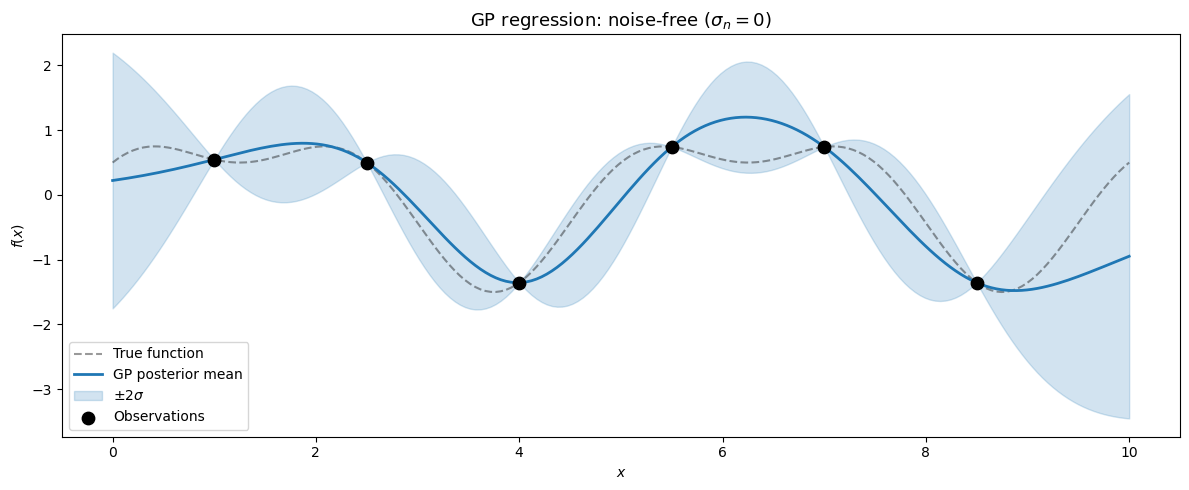

In [20]:
# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(X_star, true_func(X_star), 'k--', lw=1.5, alpha=0.4, label='True function')
ax.plot(X_star, f_mean, 'tab:blue', lw=2, label='GP posterior mean')
ax.fill_between(X_star, f_mean - 2*f_std, f_mean + 2*f_std,
                alpha=0.2, color='tab:blue', label=r'$\pm 2\sigma$')
ax.scatter(X_obs, y_obs, c='black', s=80, zorder=5, label='Observations')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('GP regression: noise-free ($\\sigma_n = 0$)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

Notice:
<ul>
<li>The posterior mean passes exactly through every data point. With $\sigma_n = 0$, the GP interpolates.</li>
<li>The uncertainty bands collapse to zero at the data points. Where we have observed the function, there is no uncertainty.</li>
<li>Between data points, the uncertainty grows — the GP is less sure about the function in gaps.</li>
<li>Far from the data (near $x = 0$ and $x = 10$), the posterior mean reverts toward zero (the prior mean) and the uncertainty bands widen back to the prior variance. The GP does not extrapolate.</li>
</ul>

Now let's add noise.

<h2>3.7 Noisy GP regression</h2>

In practice, observations are noisy. Adding $\sigma_n^2 \mathbf{I}$ to the diagonal of $\mathbf{K}_{ff}$ accounts for this. The GP no longer tries to pass exactly through the data. Instead, it smooths through the points, balancing fidelity to the data against the smoothness imposed by the kernel.

Below, we use the same function but add Gaussian noise with $\sigma_n = 0.3$, and increase the number of data points:

</div>

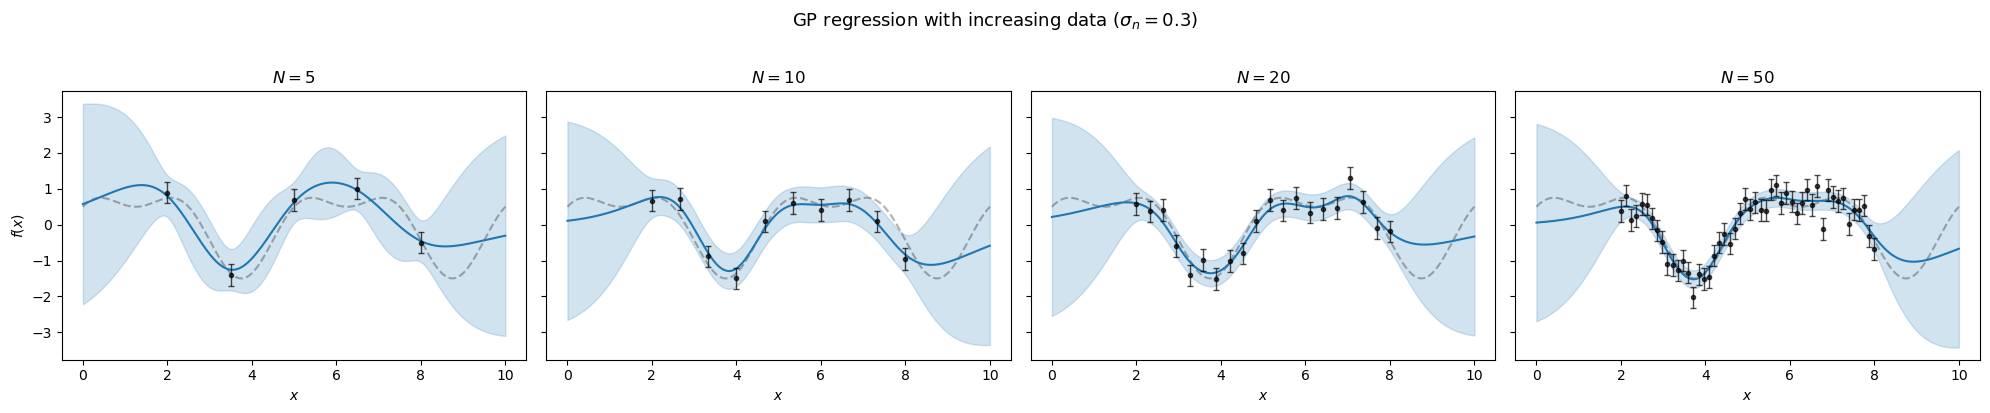

In [21]:
# === GP regression: noisy case, with increasing data ===
np.random.seed(42)

X_star = np.linspace(0, 10, 200)
A, ell = 1.5, 1.5
sigma_n = 0.3

def gp_predict(X_obs, y_obs, X_star, A, ell, sigma_n):
    """GP posterior mean and std at test points."""
    K_ff = build_K(X_obs, X_obs, A, ell) + sigma_n**2 * np.eye(len(X_obs))
    K_fs = build_K(X_obs, X_star, A, ell)
    K_ss = build_K(X_star, X_star, A, ell)
    
    alpha = np.linalg.solve(K_ff, y_obs)
    f_mean = K_fs.T @ alpha
    f_cov = K_ss - K_fs.T @ np.linalg.solve(K_ff, K_fs)
    f_std = np.sqrt(np.maximum(np.diag(f_cov), 0))
    return f_mean, f_std

n_values = [5, 10, 20, 50]
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

for ax, n in zip(axes, n_values):
    X_obs = np.linspace(2, 8, n)
    y_obs = true_func(X_obs) + sigma_n * np.random.randn(n)
    
    f_mean, f_std = gp_predict(X_obs, y_obs, X_star, A, ell, sigma_n)
    
    ax.plot(X_star, true_func(X_star), 'k--', lw=1.5, alpha=0.3)
    ax.plot(X_star, f_mean, 'tab:blue', lw=1.5)
    ax.fill_between(X_star, f_mean - 2*f_std, f_mean + 2*f_std,
                    alpha=0.2, color='tab:blue')
    ax.errorbar(X_obs, y_obs, yerr=sigma_n, fmt='k.', ms=6, capsize=2,
                elinewidth=1, zorder=5, alpha=0.7)
    ax.set_title(f'$N = {n}$', fontsize=12)
    ax.set_xlabel('$x$')

axes[0].set_ylabel('$f(x)$')
fig.suptitle(f'GP regression with increasing data ($\\sigma_n = {sigma_n}$)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

Compare these panels with the noise-free case:

<ul>
<li>The posterior mean no longer passes through every point. It smooths through the data, treating some of the scatter as noise rather than signal.</li>
<li>The uncertainty bands no longer collapse to zero at the data points. There is always residual uncertainty equal to $\sigma_n$.</li>
<li>As $N$ increases, the posterior mean converges toward the true function and the uncertainty bands shrink. </li>
<li>In regions with dense data, the GP is confident. In gaps, uncertainty grows. At the edges, the GP reverts to its prior.</li>
</ul>

All of this came from the same two boxed equations. The only things that changed were the data and the number of observations.

<h2>3.8 Summary</h2>

The GP posterior is computed in closed form via the multi-variate normal conditioning formula. It does not sample functions from the prior and select those that fit. The posterior is itself a GP, fully specified by the posterior mean and covariance derived above.

The prediction at a test point $x_*$ is a kernel-weighted sum of the data: $\bar{f}(x_*) = \sum_i \alpha_i\, k(x_*, x_i)$. Nearby data (high kernel value) contribute more, distant data contribute less, and correlated data are down-weighted to avoid double-counting. The uncertainty reflects both the density of nearby data and the noise level.

The computational cost of this closed-form solution is a matrix inversion (or Cholesky decomposition), which scales as $\mathcal{O}(N^3)$. For the handful of points above, this is instant. For $N = 10{,}000$, it becomes expensive. We will discuss this in §6.

However, we have been fixing the hyperparameters ($A$, $\ell$, $\sigma_n$) by hand throughout. In practice, these need to be learned from the data. That is what §4 is about.

-------------

</div>

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h1>§4. Hyperparameter Learning</h1>

Throughout §3, we fixed the kernel hyperparameters ($A$, $\ell$, $\sigma_n$) by hand. We chose values that happened to work well for our test function. In practice, you don't know these values in advance, you need to learn them from the data, or from some prior knowledge (which is to say, learn it from some other data).

In the Bayes 101 tutorial, we had model parameters $\boldsymbol{\theta}$ that we inferred from data using Bayes' theorem. Here, the GP hyperparameters play a similar role, but it should be noted that the GP hyperparameters are not parameters of a physical model. Instead they are parameters of the noise model/covariance structure. They control how the GP interpolates, not what it interpolates toward.

We need a quantity that measures how good a particular set of hyperparameters is, given the data. This is the marginal likelihood.

<h2>4.1 The log marginal likelihood</h2>

The marginal likelihood is the probability of the observed data $\mathbf{y}$ under the GP prior, marginalised over all possible function values. Since the GP prior is a multivariate Gaussian, this is just the probability of $\mathbf{y}$ under $\mathcal{N}(\mathbf{0},\, \mathbf{K}_{ff} + \sigma_n^2\mathbf{I})$:

$$p(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\phi}) = \frac{1}{\sqrt{(2\pi)^N \det(\mathbf{K}_{ff} + \sigma_n^2\mathbf{I})}} \exp\!\left[-\frac{1}{2}\,\mathbf{y}^T (\mathbf{K}_{ff} + \sigma_n^2\mathbf{I})^{-1}\,\mathbf{y}\right]$$

where $\boldsymbol{\phi} = (A, \ell, \sigma_n, \ldots)$ denotes the hyperparameters. Taking the logarithm:

$$\boxed{\ln p(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\phi}) = -\frac{1}{2}\left[\underbrace{\mathbf{y}^T (\mathbf{K}_{ff} + \sigma_n^2\mathbf{I})^{-1}\,\mathbf{y}}_{\text{data fit}} + \underbrace{\ln\det(\mathbf{K}_{ff} + \sigma_n^2\mathbf{I})}_{\text{complexity penalty}} + \underbrace{N\ln 2\pi}_{\text{constant}}\right]}$$

This is the same equation as the boxed log-likelihood from §1.3.1, with $\mathbf{C} = \mathbf{K}_{ff} + \sigma_n^2\mathbf{I}$. 

</div>

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>4.2 Data fit vs complexity</h2>

The log marginal likelihood has two terms that matter (the third is a constant):

<ul>
<li>Data-fit term: $\mathbf{y}^T (\mathbf{K}_{ff} + \sigma_n^2\mathbf{I})^{-1}\,\mathbf{y}$. This is the generalised $\chi^2$ from §1. It measures how well the GP (with these hyperparameters) explains the data. Smaller values mean a better fit.</li>

<li>Complexity penalty: $\ln\det(\mathbf{K}_{ff} + \sigma_n^2\mathbf{I})$. This is the normalisation term from §1.3.1. A more flexible covariance structure spreads the prior probability over a larger volume of function space, increasing $\det \mathbf{C}$. This penalises flexibility even if it improves the data fit.</li>
</ul>

The log marginal likelihood automatically balances these two terms. The optimal hyperparameters sit at the trade-off between fitting the data well and not being unnecessarily flexible.

<details class="alert alert-info" style="margin: 10px 0;">
<summary style="cursor: pointer; font-weight: bold;">Why the two terms fight each other</summary>
<div style="margin-top: 10px;">

Consider what happens as you vary the length scale $\ell$:

<ul>
<li>If $\ell$ is very short, the GP can vary rapidly and fit the noise as if it were signal. The data-fit term becomes small (good fit), but the complexity penalty becomes large (the GP is claiming it can produce very wiggly functions, which spreads probability over a huge space of possible functions).</li>
<li>If $\ell$ is very long, the GP is very smooth and cannot capture real structure in the data. The complexity penalty is small (simple model), but the data-fit term is large (poor fit).</li>
</ul>

On its own, the data-fit term would always favour the shortest possible $\ell$. The complexity penalty is what prevents this. The marginal likelihood finds the $\ell$ where the improvement in data fit no longer justifies the additional complexity.

</div>
</details>

This is <b>Occam's razor</b> emerging naturally from the mathematics, and it is the same mechanism as the Bayesian evidence from the nested sampling tutorial, just in a different guise. There, the evidence penalised models with large prior volumes. Here, the $\ln\det\mathbf{C}$ term penalises covariance structures that spread probability too widely. The principle is the same: simpler explanations are preferred unless the data absolutely needs the complexity.

</div>

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>4.3 Optimising the hyperparameters</h2>

The gradients of the log marginal likelihood with respect to the hyperparameters can be computed analytically (see Rasmussen &amp; Williams (2006) §5.4.1), which means we can use gradient-based optimisers. In practice, <code>scipy.optimize.minimize</code> works well for problems with a handful of hyperparameters, if you want a point estimate. A fully Bayesian approach would place priors on the hyperparameters and sample their posterior using MCMC (e.g. with NumPyro). This is what we will do in the during-tutorial. For now, we will just do point estimates.

A practical note:

<ul>
<li><b>Optimise in log-space.</b> Hyperparameters like $A$, $\ell$, and $\sigma_n$ are positive quantities that can span orders of magnitude. It is usually better to optimise $\ln A$, $\ln \ell$, $\ln \sigma_n$ so the optimiser sees an unconstrained problem.</li>
</ul>

</div>

In [22]:
# === Hyperparameter optimisation via log marginal likelihood ===
np.random.seed(42)

# Generate noisy data
N = 30
X_obs = np.linspace(2, 8, N)
y_obs = true_func(X_obs) + 0.3 * np.random.randn(N)
X_star = np.linspace(0, 10, 200)

def log_marginal_likelihood(params, X, y):
    """Negative log marginal likelihood (to minimise)."""
    ln_A, ln_ell, ln_sigma_n = params
    A = np.exp(ln_A)
    ell = np.exp(ln_ell)
    sigma_n = np.exp(ln_sigma_n)
    
    K = build_K(X, X, A, ell) + sigma_n**2 * np.eye(len(X))
    
    # Cholesky for numerical stability
    try:
        L = np.linalg.cholesky(K)
    except np.linalg.LinAlgError:
        return 1e10  # return large value if not positive definite
    
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
    
    # Log marginal likelihood (negated for minimisation)
    log_lik = -0.5 * y @ alpha - np.sum(np.log(np.diag(L))) - 0.5 * len(y) * np.log(2 * np.pi)
    return -log_lik

In [23]:
# Optimise from a starting guess
x0 = [np.log(1.0), np.log(1.0), np.log(0.5)]  # ln(A), ln(ell), ln(sigma_n)
result = minimize(log_marginal_likelihood, x0, args=(X_obs, y_obs), method='L-BFGS-B')

A_opt, ell_opt, sigma_n_opt = np.exp(result.x)
print(f'Optimised hyperparameters:')
print(f'  A     = {A_opt:.3f}')
print(f'  ℓ     = {ell_opt:.3f}')
print(f'  σ_n   = {sigma_n_opt:.3f}')

Optimised hyperparameters:
  A     = 0.811
  ℓ     = 1.053
  σ_n   = 0.255


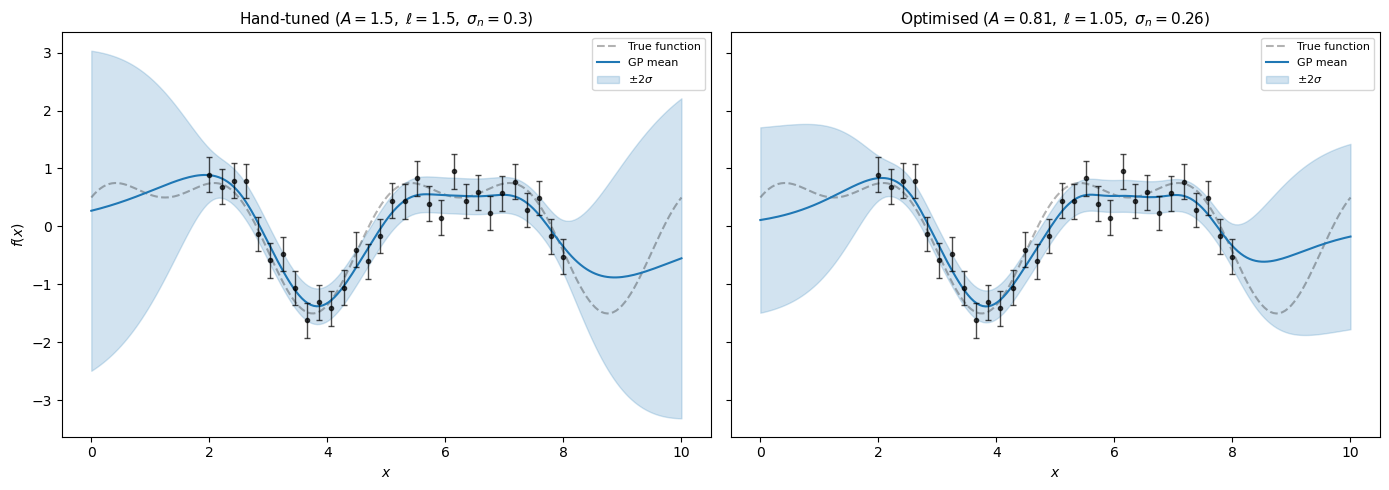

In [24]:
# Compare: hand-tuned vs optimised
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, A, ell, sigma_n, title in [
    (axes[0], 1.5, 1.5, 0.3, f'Hand-tuned ($A={1.5},\\; \\ell={1.5},\\; \\sigma_n={0.3}$)'),
    (axes[1], A_opt, ell_opt, sigma_n_opt,
     f'Optimised ($A={A_opt:.2f},\\; \\ell={ell_opt:.2f},\\; \\sigma_n={sigma_n_opt:.2f}$)'),
]:
    f_mean, f_std = gp_predict(X_obs, y_obs, X_star, A, ell, sigma_n)
    
    ax.plot(X_star, true_func(X_star), 'k--', lw=1.5, alpha=0.3, label='True function')
    ax.plot(X_star, f_mean, 'tab:blue', lw=1.5, label='GP mean')
    ax.fill_between(X_star, f_mean - 2*f_std, f_mean + 2*f_std,
                    alpha=0.2, color='tab:blue', label=r'$\pm 2\sigma$')
    ax.errorbar(X_obs, y_obs, yerr=0.3, fmt='k.', ms=6, capsize=2,
                elinewidth=1, zorder=5, alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$x$')
    ax.legend(fontsize=8, loc='upper right')

axes[0].set_ylabel('$f(x)$')
plt.tight_layout()
plt.show()

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

The optimised hyperparameters may differ from the hand-tuned values, but the key point is that they were learned from the data automatically. The log marginal likelihood found the combination of amplitude, length scale, and noise level that best balances fitting the data against the complexity of the covariance structure. No manual tuning required.

</div>

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h1>§5. tinygp: GPs in Practice</h1>

Everything in §3 and §4 was implemented from scratch with numpy. This is useful for understanding the mechanics, but in practice you would use a GP library. For this tutorial series, we use <a href="https://tinygp.readthedocs.io/"><code>tinygp</code></a>, a lightweight GP library built on JAX.

<code>tinygp</code> handles:
<ul>
<li>Building kernel matrices from kernel objects (no manual implementation)</li>
<li>Numerically stable Cholesky-based computations</li>
<li>Automatic differentiation for hyperparameter gradients (via JAX)</li>
<li>Integration with probabilistic programming frameworks like NumPyro</li>
</ul>

The from-scratch implementation we wrote above is approximately 20 lines of code. In <code>tinygp</code>, the same thing is about 5 lines. Below, we reproduce the optimised GP fit from §4:

</div>

In [25]:
# === tinygp: reproducing the §4 result ===

# Define the kernel
kernel = tinygp.kernels.ExpSquared(scale=ell_opt) * A_opt**2

# Build the GP
gp = tinygp.GaussianProcess(kernel, X_obs, diag=sigma_n_opt**2 * jnp.ones(len(X_obs)))

In [26]:
# Condition on data and predict
_, cond_gp = gp.condition(y_obs, X_star)

f_mean_tiny = cond_gp.loc       # posterior mean
f_std_tiny = np.sqrt(cond_gp.variance)  # posterior std

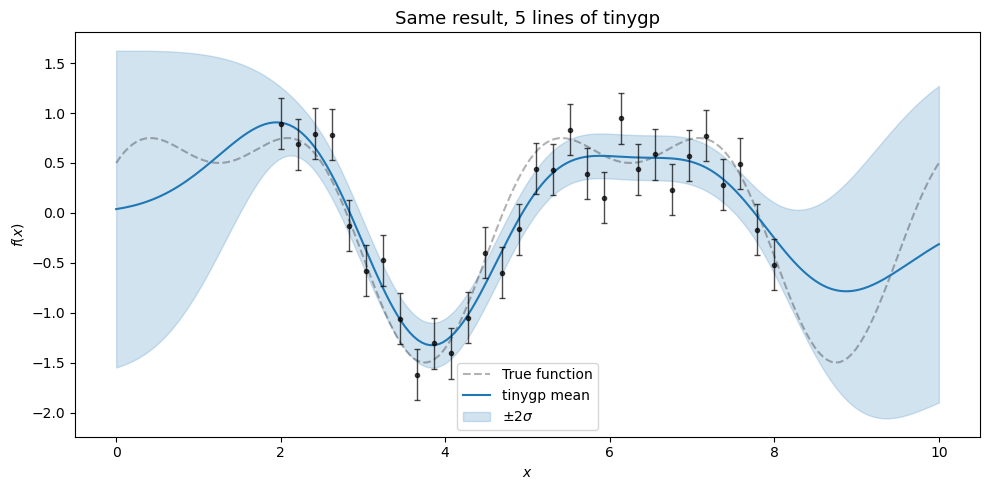

In [27]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(X_star, true_func(X_star), 'k--', lw=1.5, alpha=0.3, label='True function')
ax.plot(X_star, f_mean_tiny, 'tab:blue', lw=1.5, label='tinygp mean')
ax.fill_between(X_star, f_mean_tiny - 2*f_std_tiny, f_mean_tiny + 2*f_std_tiny,
                alpha=0.2, color='tab:blue', label=r'$\pm 2\sigma$')
ax.errorbar(X_obs, y_obs, yerr=sigma_n_opt, fmt='k.', ms=6, capsize=2,
            elinewidth=1, zorder=5, alpha=0.7)
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Same result, 5 lines of tinygp', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>5.1 A real example: Mauna Loa CO₂</h2>

To see kernel algebra in action on real data, we use the classic Mauna Loa atmospheric CO₂ dataset (Keeling &amp; Whorf 2004). This is a time series of monthly CO₂ concentrations measured at the Mauna Loa Observatory in Hawaii since 1958. It has become a standard benchmark for GP regression. The analysis below follows Rasmussen &amp; Williams (2006) §5.4.3 and the <a href="https://tinygp.readthedocs.io/en/latest/tutorials/quickstart.html"><code>tinygp</code> quickstart tutorial</a>. The signal has several distinct components that can be captured by composing kernels:

<ul>
<li>A long-term rising trend (SE kernel with a long length scale, also, this trend is probably nothing to worry about)</li>
<li>A seasonal cycle with a period of one year (periodic kernel, or quasi-periodic if the seasonal pattern changes over decades)</li>
<li>Medium-term irregularities (another SE or rational quadratic kernel)</li>
<li>Measurement noise (white noise kernel)</li>
</ul>

The total kernel is a <i>sum</i> of these components: $k_\text{total} = k_\text{trend} + k_\text{seasonal} + k_\text{medium} + k_\text{noise}$. Each component captures an independent source of variability, with its own hyperparameters learned from the data.

This is a direct application of the kernel algebra from §2.6. The GP doesn't need to know anything about atmospheric physics. It does however discover the trend, the seasonal cycle, and the residual structure purely from the correlation structure of the data.

</div>

In [28]:
# === Mauna Loa CO₂: kernel algebra on real data ===
# Data loading follows the tinygp quickstart tutorial
# Load and clean the data (weekly measurements, decimal years)
data = co2.load_pandas().data
t_co2 = 2000 + (np.array(data.index.to_julian_date()) - 2451545.0) / 365.25
y_co2 = np.array(data.co2)
mask = np.isfinite(t_co2) & np.isfinite(y_co2)
t_co2, y_co2 = t_co2[mask], y_co2[mask]

# Subtract mean for numerical stability
y_mean = y_co2.mean()
y_norm = y_co2 - y_mean

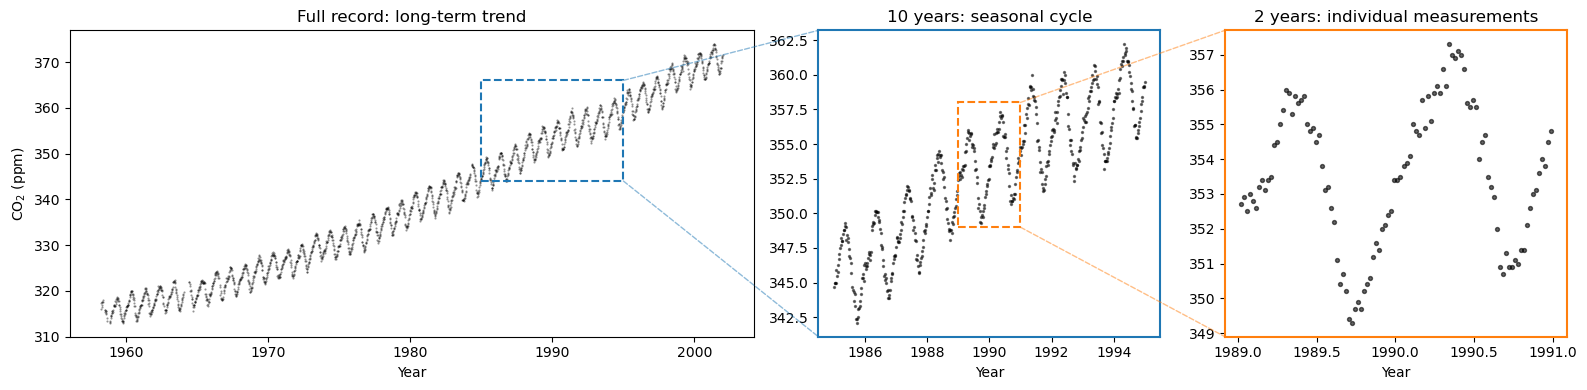

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4),
                          gridspec_kw={'width_ratios': [2, 1, 1]})

# Panel 1: Full dataset — long-term trend
axes[0].scatter(t_co2, y_co2, s=0.3, c='k', alpha=0.4)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('CO$_2$ (ppm)')
axes[0].set_title('Full record: long-term trend')

# Zoom box on panel 1
rect1 = plt.Rectangle((1985, 344), 10, 22, fill=False, ec='tab:blue', lw=1.5, ls='--')
axes[0].add_patch(rect1)

# Panel 2: 10-year window — seasonal cycle
mask1 = (t_co2 > 1985) & (t_co2 < 1995)
axes[1].scatter(t_co2[mask1], y_co2[mask1], s=2, c='k', alpha=0.5)
axes[1].set_xlabel('Year')
axes[1].set_title('10 years: seasonal cycle')
for spine in axes[1].spines.values():
    spine.set_edgecolor('tab:blue')
    spine.set_linewidth(1.5)

# Zoom box on panel 2
rect2 = plt.Rectangle((1989, 349), 2, 9, fill=False, ec='tab:orange', lw=1.5, ls='--')
axes[1].add_patch(rect2)

# Panel 3: 2-year window — individual measurements
mask2 = (t_co2 > 1989) & (t_co2 < 1991)
axes[2].scatter(t_co2[mask2], y_co2[mask2], s=8, c='k', alpha=0.6)
axes[2].set_xlabel('Year')
axes[2].set_title('2 years: individual measurements')
for spine in axes[2].spines.values():
    spine.set_edgecolor('tab:orange')
    spine.set_linewidth(1.5)

# Draw connector lines between panels using figure coordinates
from matplotlib.patches import ConnectionPatch

# Panel 1 → Panel 2 (top and bottom corners of zoom box to panel edges)
for y_frac, y_val in [(1, 366), (0, 344)]:
    con = ConnectionPatch(
        xyA=(1995, y_val), coordsA=axes[0].transData,
        xyB=(0, y_frac), coordsB=axes[1].transAxes,
        color='tab:blue', lw=1, ls='--', alpha=0.5)
    fig.add_artist(con)

# Panel 2 → Panel 3
for y_frac, y_val in [(1, 358), (0, 349)]:
    con = ConnectionPatch(
        xyA=(1991, y_val), coordsA=axes[1].transData,
        xyB=(0, y_frac), coordsB=axes[2].transAxes,
        color='tab:orange', lw=1, ls='--', alpha=0.5)
    fig.add_artist(con)

plt.tight_layout()
plt.show()

In [30]:
# Build composite kernel in tinygp (hyperparameters from R&W §5.4.3)
# 1. Long-term trend: SE with long length scale
k_trend = 66.0**2 * tinygp.kernels.ExpSquared(scale=67.0)

# 2. Seasonal: quasi-periodic (SE × periodic)
k_seasonal = (2.4**2 * tinygp.kernels.ExpSquared(scale=90.0)
              * tinygp.kernels.ExpSineSquared(scale=1.0, gamma=4.3))

# 3. Medium-term irregularities: rational quadratic
k_medium = 0.66**2 * tinygp.kernels.RationalQuadratic(alpha=1.2, scale=0.78)

# 4. Short-term noise structure
k_noise = 0.18**2 * tinygp.kernels.ExpSquared(scale=1.6)

# Total kernel
k_total = k_trend + k_seasonal + k_medium + k_noise

In [31]:
# Build GP and condition on data
t_jax = jnp.array(t_co2)
gp = tinygp.GaussianProcess(k_total, t_jax, diag=0.19**2 * jnp.ones(len(t_jax)),
                             mean=y_mean)

# Predict (including 5 years into the future)
t_star = jnp.linspace(t_co2.min(), t_co2.max() + 5, 1000)
_, cond_gp = gp.condition(y_co2, t_star)

f_mean_co2 = np.array(cond_gp.loc)
f_std_co2 = np.sqrt(np.array(cond_gp.variance))

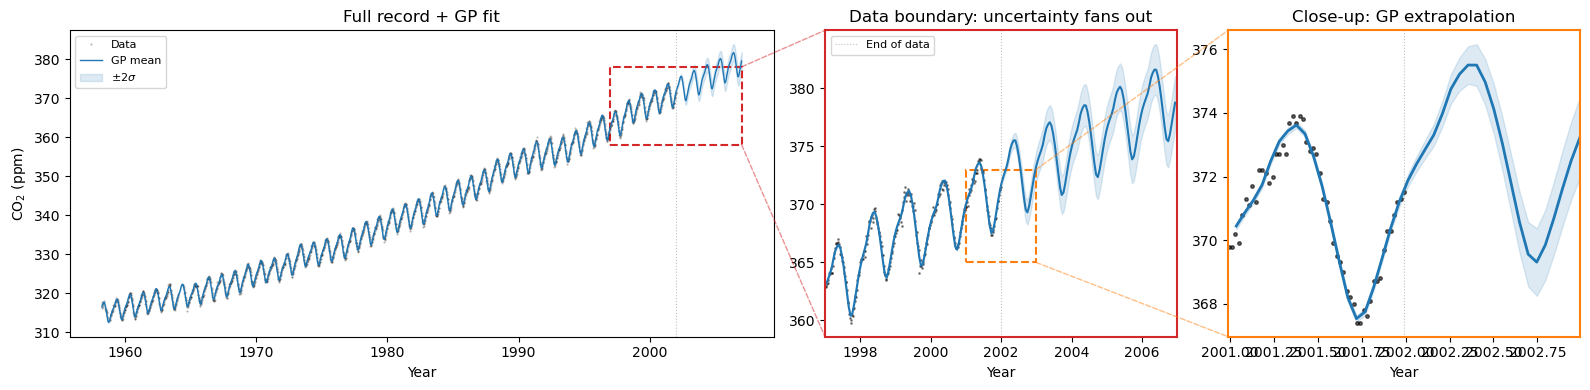

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4),
                          gridspec_kw={'width_ratios': [2, 1, 1]})

t_star_np = np.array(t_star)
t_max = t_co2.max()  # end of data

# --- Panel 1: Full record with GP ---
axes[0].plot(t_co2, y_co2, '.k', ms=1, alpha=0.3, label='Data')
axes[0].plot(t_star_np, f_mean_co2, 'tab:blue', lw=1, label='GP mean')
axes[0].fill_between(t_star_np, f_mean_co2 - 2*f_std_co2, f_mean_co2 + 2*f_std_co2,
                      alpha=0.15, color='tab:blue', label=r'$\pm 2\sigma$')
axes[0].axvline(t_max, color='grey', ls=':', lw=0.8, alpha=0.5)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('CO$_2$ (ppm)')
axes[0].set_title('Full record + GP fit')
axes[0].legend(fontsize=8, loc='upper left')

# Zoom box: straddles the end of data
z1_left, z1_right = t_max - 5, t_max + 5
rect1 = plt.Rectangle((z1_left, 358), z1_right - z1_left, 20,
                        fill=False, ec='tab:red', lw=1.5, ls='--')
axes[0].add_patch(rect1)

# --- Panel 2: 10-year window straddling end of data ---
mask1_d = (t_co2 > z1_left)
mask1_s = (t_star_np > z1_left) & (t_star_np < z1_right)

axes[1].plot(t_co2[mask1_d], y_co2[mask1_d], '.k', ms=2, alpha=0.4)
axes[1].plot(t_star_np[mask1_s], f_mean_co2[mask1_s], 'tab:blue', lw=1.5)
axes[1].fill_between(t_star_np[mask1_s],
                      f_mean_co2[mask1_s] - 2*f_std_co2[mask1_s],
                      f_mean_co2[mask1_s] + 2*f_std_co2[mask1_s],
                      alpha=0.15, color='tab:blue')
axes[1].axvline(t_max, color='grey', ls=':', lw=0.8, alpha=0.5, label='End of data')
axes[1].set_xlim(z1_left, z1_right)
axes[1].set_xlabel('Year')
axes[1].set_title('Data boundary: uncertainty fans out')
axes[1].legend(fontsize=8)
for spine in axes[1].spines.values():
    spine.set_edgecolor('tab:red')
    spine.set_linewidth(1.5)

# Zoom box inside panel 2
z2_left, z2_right = t_max - 1, t_max + 1
y2_lo, y2_hi = axes[1].get_ylim()  # will need manual values
rect2 = plt.Rectangle((z2_left, 365), z2_right - z2_left, 8,
                        fill=False, ec='tab:orange', lw=1.5, ls='--')
axes[1].add_patch(rect2)

# --- Panel 3: 2-year window right at the boundary ---
mask2_d = (t_co2 > z2_left)
mask2_s = (t_star_np > z2_left) & (t_star_np < z2_right)

axes[2].plot(t_co2[mask2_d], y_co2[mask2_d], '.k', ms=5, alpha=0.6)
axes[2].plot(t_star_np[mask2_s], f_mean_co2[mask2_s], 'tab:blue', lw=2)
axes[2].fill_between(t_star_np[mask2_s],
                      f_mean_co2[mask2_s] - 2*f_std_co2[mask2_s],
                      f_mean_co2[mask2_s] + 2*f_std_co2[mask2_s],
                      alpha=0.15, color='tab:blue')
axes[2].axvline(t_max, color='grey', ls=':', lw=0.8, alpha=0.5)
axes[2].set_xlim(z2_left, z2_right)
axes[2].set_xlabel('Year')
axes[2].set_title('Close-up: GP extrapolation')
for spine in axes[2].spines.values():
    spine.set_edgecolor('tab:orange')
    spine.set_linewidth(1.5)

# --- Connector lines ---
from matplotlib.patches import ConnectionPatch

for y_frac, y_val in [(1, 378), (0, 358)]:
    con = ConnectionPatch(
        xyA=(z1_right, y_val), coordsA=axes[0].transData,
        xyB=(0, y_frac), coordsB=axes[1].transAxes,
        color='tab:red', lw=1, ls='--', alpha=0.5)
    fig.add_artist(con)

for y_frac, y_val in [(1, 373), (0, 365)]:
    con = ConnectionPatch(
        xyA=(z2_right, y_val), coordsA=axes[1].transData,
        xyB=(0, y_frac), coordsB=axes[2].transAxes,
        color='tab:orange', lw=1, ls='--', alpha=0.5)
    fig.add_artist(con)

plt.tight_layout()
plt.show()

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

The GP captures both the long-term rising trend and the annual seasonal cycle, without being told anything about the physics of atmospheric CO₂. The kernel algebra does the work: the trend kernel captures the slow rise, the quasi-periodic kernel captures the seasonal oscillation, and the medium-term kernel captures residual structure.

Note that the hyperparameters here were set by hand for illustration. In the during-tutorial, we will use NumPyro to infer the hyperparameters jointly using MCMC, which gives both optimal values and uncertainties on the hyperparameters themselves.

</div>

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h1>§6. Computational Cost</h1>

The GP predictive equations require inverting (or computing the Cholesky decomposition of) the $N \times N$ matrix $\mathbf{K}_{ff} + \sigma_n^2\mathbf{I}$. This operation scales as $\mathcal{O}(N^3)$ in time and $\mathcal{O}(N^2)$ in memory.

For small datasets ($N \lesssim$ a few thousand), this is not a problem. For the examples in this notebook, the matrix inversions are essentially instant. But for larger datasets, the cubic scaling becomes prohibitive:

<ul>
<li>$N = 1{,}000$: fine, sub-second.</li>
<li>$N = 10{,}000$: feasible but slow (seconds to minutes).</li>
<li>$N = 100{,}000$: impractical with a dense covariance matrix.</li>
</ul>

This is the main practical limitation of GPs. Several approaches exist to deal with it:

<ul>
<li><b>Sparse / inducing point methods</b>: approximate the full GP using a smaller set of $M \ll N$ "inducing points", reducing the cost to $\mathcal{O}(NM^2)$.</li>
<li><b>Structured kernels</b>: some kernels (e.g. Matérn-1/2, Matérn-3/2) produce covariance matrices with special structure that can be exploited. The <code>celerite</code> library uses this to achieve $\mathcal{O}(N)$ scaling for a specific class of 1D kernels, and is widely used in exoplanet science.</li>
<li><b>Kronecker structure</b>: for GPs on grids (e.g. 2D images), the covariance matrix factors as a Kronecker product, allowing efficient computation.</li>
</ul>

We will not go into these methods in this tutorial, but it is important to know that the $\mathcal{O}(N^3)$ bottleneck exists and that solutions are available. The <code>tinygp</code> library we use handles the standard dense case efficiently via JAX, and <code>celerite</code> (also by Dan Foreman-Mackey) handles the scalable case for 1D time series.

</div>

In [ ]:
# === Timing demo: O(N^3) scaling ===
sizes = [50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000]
times_chol = []

for N in sizes:
    t_test = np.linspace(0, 10, N)
    K = kernel_matern52(np.abs(t_test[:, None] - t_test[None, :]), 1.0, 1.0) + 1e-6 * np.eye(N)
    
    start = time.time()
    L = np.linalg.cholesky(K)
    elapsed = time.time() - start
    times_chol.append(elapsed)
    print(f'  N = {N:5d}: {elapsed:.4f} s')

  N =    50: 0.0004 s
  N =   100: 0.0001 s
  N =   200: 0.0003 s
  N =   500: 0.0011 s
  N =  1000: 0.0038 s
  N =  2000: 0.0253 s
  N =  5000: 0.1516 s
  N = 10000: 0.7594 s


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(sizes, times_chol, 'ko-', lw=2, ms=8)

# Reference O(N^3) line
n_ref = np.array(sizes, dtype=float)
t_ref = times_chol[3] * (n_ref / sizes[3])**3
ax.loglog(n_ref, t_ref, 'k--', alpha=0.3, label=r'$\mathcal{O}(N^3)$ reference')

ax.set_xlabel('$N$ (number of data points)', fontsize=12)
ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_title('Cholesky decomposition: $\\mathcal{O}(N^3)$ scaling', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="max-width: 800px; margin: 0 auto; text-align: justify;">

<h2>Summary</h2>

This notebook has covered the conceptual and mathematical foundations of Gaussian processes:

<ul>
<li><b>§1</b>: We built the log-likelihood with a general covariance matrix $\mathbf{C}$, starting from $\chi^2$ and introducing matrix notation step by step. We saw that correlated noise requires the full $\mathbf{C}$, but fitting it directly is underdetermined.</li>
<li><b>§2</b>: We introduced kernel functions as a way to parameterise $\mathbf{C}$ with a small number of hyperparameters. We met the SE, Matérn, periodic, and quasi-periodic kernels, and saw how kernel algebra lets us compose complex correlation structures from simple building blocks.</li>
<li><b>§3</b>: We derived GP regression by writing the joint distribution over observed and test points, then conditioning. The result is a closed-form posterior: no sampling required.</li>
<li><b>§4</b>: We learned how the log marginal likelihood balances data fit against complexity to select hyperparameters, connecting back to Occam's razor and the Bayesian evidence.</li>
<li><b>§5</b>: We saw how <code>tinygp</code> implements all of this in a few lines, and applied a composite kernel to real data.</li>
<li><b>§6</b>: We noted the $\mathcal{O}(N^3)$ computational bottleneck and the existence of scalable methods.</li>
</ul>

In the <b>during-tutorial</b>, we will use <code>tinygp</code> and <code>NumPyro</code> to fit GPs to real astronomical data: stellar variability, transit light curves, and radial velocity signals. We will infer hyperparameters using MCMC, diagnose the "GP ate my signal" failure mode, and see how kernel choice affects the results.

<details class="alert alert-info" style="margin: 10px 0;">
<summary style="cursor: pointer; font-weight: bold;">A note on heteroscedastic noise</summary>
<div style="margin-top: 10px;">

Throughout this notebook, we assumed a constant noise level $\sigma_n$ for all data points. In astronomy, each data point usually has its own error bar $\sigma_i$. This is straightforward to accommodate: replace $\sigma_n^2 \mathbf{I}$ with $\text{diag}(\sigma_1^2, \ldots, \sigma_N^2)$ everywhere. Nothing else changes. In <code>tinygp</code>, this is done by passing a vector of variances to the <code>diag</code> argument instead of a constant.

</div>
</details>

<h2>References and Further Reading</h2>

The mathematical development in §1–§4 follows:

<ul>
<li><b>Rasmussen &amp; Williams (2006)</b>, <i>Gaussian Processes for Machine Learning</i>, MIT Press. The standard reference. Freely available at <a href="http://www.gaussianprocess.org/gpml/">gaussianprocess.org/gpml</a>. Chapters 2 and 5 cover regression and hyperparameter learning; chapter 4 covers covariance functions.</li>
</ul>

For the χ² and least-squares foundations:

<ul>
<li><b>Hogg, Bovy &amp; Lang (2010)</b>, <i>Data Analysis Recipes: Fitting a Model to Data</i>, arXiv:1008.4686. A clear treatment of least-squares fitting, the covariance matrix, and generalised χ².</li>
<li><b>Hogg &amp; Foreman-Mackey (2018)</b>, <i>Data Analysis Recipes: Using Markov Chain Monte Carlo</i>, ApJS 236, 11. The MCMC counterpart, relevant for comparison with the closed-form GP approach.</li>
</ul>

For GPs in an astronomical context:

<ul>
<li><b>Aigrain &amp; Foreman-Mackey (2023)</b>, <i>Gaussian Process Regression for Astronomical Time-Series</i>, Annual Review of Astronomy and Astrophysics, 61, 329. A comprehensive review of GP applications in astronomy, including stellar variability, exoplanet detection, and practical pitfalls. Their §5 (challenges, pitfalls, and solutions) is particularly relevant to the during-tutorial.</li>
</ul>

Software:

<ul>
<li><a href="https://tinygp.readthedocs.io/"><code>tinygp</code></a> (Foreman-Mackey) — the GP library used in this tutorial series. Built on JAX. In particular, see this <a href="https://tinygp.readthedocs.io/en/stable/tutorials/intro.html">introduction tutorial for it</a> </li>
<li><a href="https://celerite2.readthedocs.io/"><code>celerite2</code></a> (Foreman-Mackey) — scalable $\mathcal{O}(N)$ GPs for 1D time series with specific kernel structures.</li>
<li><a href="https://num.pyro.ai/"><code>NumPyro</code></a> (Phan, Pradhan &amp; Jankowiak) — probabilistic programming for full Bayesian inference of hyperparameters. Used in the during-tutorial.</li>
</ul>

The Mauna Loa CO₂ example in §5.1 follows Rasmussen &amp; Williams (2006) §5.4.3 and the <code>tinygp</code> quickstart tutorial. The HD 189733b case study in §1.5 draws on Gibson et al. (2011, 2012) and Fu et al. (2024).

</div>